# Pipeline complet `bottle` — Prétraitement + Autoencodeur convolutionnel (détection d'anomalies, MVTec-AD)

Ce notebook implémente le pipeline décrit dans `preprocessing_bottle_fr.md`, en deux parties :

**Partie 1 — Prétraitement** (étapes 1 à 6, dont 3.1 à 3.11) :
1. Inventaire et vérification des fichiers (images + masques).
2. Redimensionnement des images (128×128 ou 256×256) et des masques (`ground_truth`).
3. Normalisation des pixels dans `[0, 1]`.
4. Split train/validation sur les images saines uniquement.
5. Augmentation (Albumentations) appliquée uniquement à l'entraînement.
6. Pipelines `tf.data` pour train/val/test, étude de déséquilibre de classe.

**Partie 2 — Autoencodeur convolutionnel** (étapes 7 à 15) :
7. Conception de l'architecture (encodeur / bottleneck / décodeur).
8. Construction et lecture du `summary()` (incl. ratio de compression).
9. Vérification sur un vrai batch du pipeline.
10. Compilation (`Adam`, loss `MSE`, métrique `SSIM`).
11. Suivi MLflow (params, métriques par epoch, artifacts).
12. Entraînement (cible = entrée, reconstruction).
13. Courbes d'apprentissage (loss + SSIM, train/validation).
14. Exemples de reconstruction après entraînement.
15. Prochaine étape (score d'anomalie).

**Bibliothèques** : `pillow` (I/O), `opencv` (resize images), `scikit-image` (resize masques binaires), `albumentations` (augmentation), `tensorflow`/`keras` (pipeline + modèle), `mlflow` (suivi des runs).

> Adapter `DATA_DIR` au chemin réel de ton dataset `bottle` avant exécution.

In [176]:
import time
_notebook_start_time = time.time()  # chronométrage global du notebook (affiché en toute dernière cellule)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # réduit les logs TensorFlow

from pathlib import Path
import numpy as np
import cv2
from PIL import Image
from skimage.transform import resize as sk_resize
import albumentations as A
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Configuration (correspond à la section 1 du md — choix de la taille cible)

In [177]:
DATA_DIR = Path("data/bottle")   # <- à adapter à ton chemin local
IMG_SIZE = 128                    # 128 pour itérer vite, 256 pour la version finale
BATCH_SIZE = 16
VAL_FRACTION = 0.15
SEED = 42

np.random.seed(SEED)

## Étape 3.1 — Inventaire et vérification des fichiers

- Liste des images saines (`train/good`, `test/good`) et des dossiers de défauts (`test/<defect>`).
- Vérification que chaque image défectueuse a bien son masque correspondant dans `ground_truth/<defect>`.
- Détection de fichiers corrompus.

In [178]:
train_good = sorted((DATA_DIR / "train" / "good").glob("*.png"))
test_good = sorted((DATA_DIR / "test" / "good").glob("*.png"))
defect_dirs = [d for d in (DATA_DIR / "test").iterdir() if d.is_dir() and d.name != "good"]
defect_names = sorted(d.name for d in defect_dirs)

print("train/good :", len(train_good))
print("test/good  :", len(test_good))
print("classes de défauts :", defect_names)

train/good : 209
test/good  : 20
classes de défauts : ['broken_large', 'broken_small', 'contamination']


In [179]:
# Vérifie la correspondance image <-> masque pour chaque classe de défaut
# Convention MVTec-AD : ground_truth/<defect>/<id>_mask.png <-> test/<defect>/<id>.png
for name in defect_names:
    imgs = sorted((DATA_DIR / "test" / name).glob("*.png"))
    masks = sorted((DATA_DIR / "ground_truth" / name).glob("*_mask.png"))
    assert len(imgs) == len(masks), f"Mismatch images/masks pour {name}: {len(imgs)} vs {len(masks)}"
    print(f"  {name}: {len(imgs)} images / {len(masks)} masks — OK")

  broken_large: 20 images / 20 masks — OK
  broken_small: 22 images / 22 masks — OK
  contamination: 21 images / 21 masks — OK


In [180]:
def verify_images(paths):
    """Retourne la liste des fichiers illisibles/corrompus."""
    bad = []
    for p in paths:
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            bad.append(p)
    return bad

bad_files = verify_images(train_good + test_good)
print("Fichiers corrompus détectés :", len(bad_files))
if bad_files:
    print(bad_files)

Fichiers corrompus détectés : 0


## Étapes 3.2 à 3.4 — Chargement, redimensionnement (images + masques) et normalisation

- **Images** : Pillow pour la lecture (conversion RGB systématique), OpenCV pour le resize (`INTER_AREA`, adapté à la réduction de taille).
- **Masques** : lecture Pillow en niveaux de gris, resize scikit-image en **plus proche voisin** (`order=0`) pour ne pas casser la binarité, puis re-binarisation explicite.

In [181]:
def load_and_resize_image(path, size=IMG_SIZE):
    """Charge une image et la redimensionne en (size, size, 3), RGB, uint8."""
    img = Image.open(path).convert("RGB")
    img = np.array(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img


def load_and_resize_mask(path, size=IMG_SIZE):
    """Charge un masque binaire et le redimensionne sans casser la binarité."""
    mask = Image.open(path).convert("L")
    mask = np.array(mask)
    mask = sk_resize(mask, (size, size), order=0, preserve_range=True, anti_aliasing=False)
    mask = (mask > 127).astype(np.uint8)
    return mask


def normalize(img):
    """Normalise une image uint8 [0,255] en float32 [0,1]."""
    return img.astype(np.float32) / 255.0

In [182]:
# Vérification rapide sur un exemple
sample_img = load_and_resize_image(train_good[0])
print("Image redimensionnée :", sample_img.shape, sample_img.dtype)

if defect_names:
    sample_mask_path = sorted((DATA_DIR / "ground_truth" / defect_names[0]).glob("*_mask.png"))[0]
    sample_mask = load_and_resize_mask(sample_mask_path)
    print("Masque redimensionné :", sample_mask.shape, "valeurs uniques :", np.unique(sample_mask))

sample_norm = normalize(sample_img)
print("Image normalisée, plage :", sample_norm.min(), "-", sample_norm.max())

Image redimensionnée : (128, 128, 3) uint8
Masque redimensionné : (128, 128) valeurs uniques : [0 1]
Image normalisée, plage : 0.12156863 - 1.0


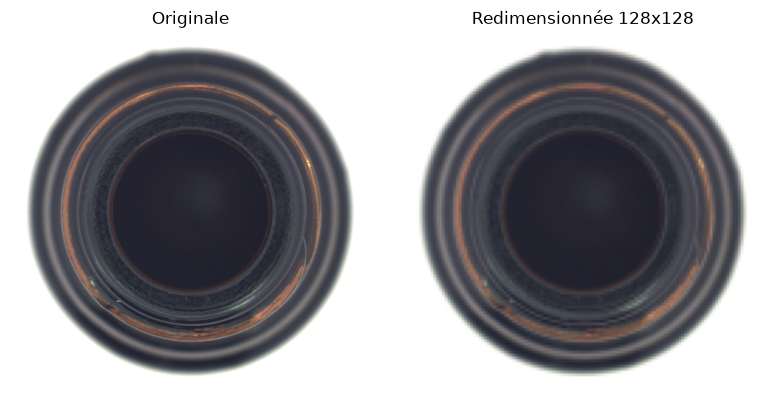

In [183]:
# Aperçu visuel : image originale vs redimensionnée
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(train_good[0]).convert("RGB"))
axes[0].set_title("Originale")
axes[0].axis("off")
axes[1].imshow(sample_img)
axes[1].set_title(f"Redimensionnée {IMG_SIZE}x{IMG_SIZE}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Étape 3.5 — Split train / validation (images saines uniquement)

Split aléatoire sur les chemins de fichiers de `train/good`, avant tout chargement en mémoire. Les dossiers `test/` (sains et défectueux) ne sont jamais utilisés pour ce split — ils servent uniquement à l'évaluation finale.

In [184]:
train_paths, val_paths = train_test_split(
    train_good, test_size=VAL_FRACTION, random_state=SEED
)
print(f"Train : {len(train_paths)} images")
print(f"Validation : {len(val_paths)} images")

Train : 177 images
Validation : 32 images


## Étape 3.6 — Pipeline d'augmentation (Albumentations) — images saines d'entraînement uniquement

Transformations choisies, cohérentes avec un contexte industriel (une bouteille doit rester reconnaissable comme "normale") :
- `HorizontalFlip` — symétrie horizontale
- `Rotate` — rotation légère (±15°)
- `ShiftScaleRotate` — translation + mise à l'échelle légère (centrage/zoom imparfait de la caméra)
- `RandomBrightnessContrast` — variations d'éclairage

Appliquées uniquement sur le split d'entraînement (`train_paths`), jamais sur validation/test.

In [185]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_REPLICATE),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
        border_mode=cv2.BORDER_REPLICATE, p=0.5,
    ),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
])

e:\Projets\_workspace\aelion-4-trainning\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


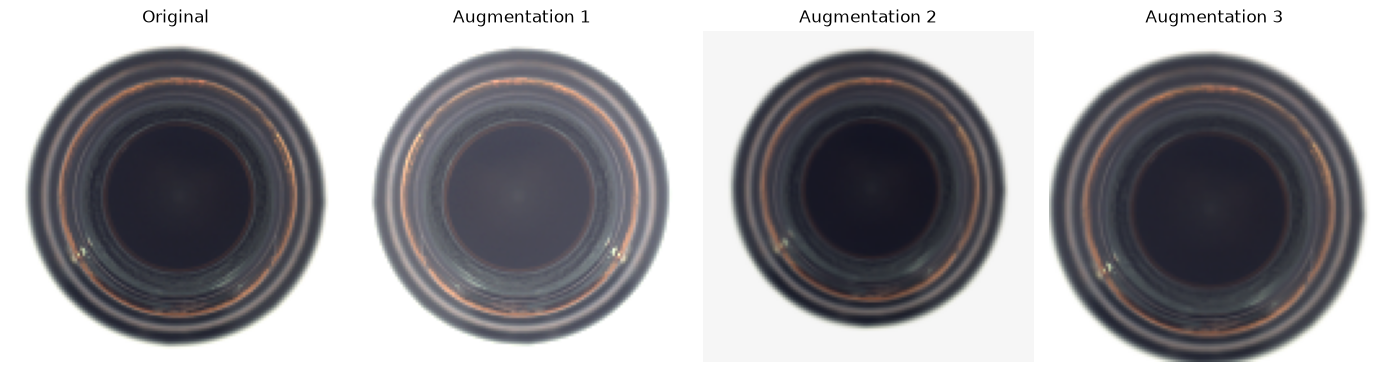

In [186]:
# Aperçu rapide de quelques tirages d'augmentation sur une même image
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
base_img = load_and_resize_image(train_paths[0])
axes[0].imshow(base_img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 4):
    aug_img = train_transform(image=base_img)["image"]
    axes[i].imshow(aug_img); axes[i].set_title(f"Augmentation {i}"); axes[i].axis("off")
plt.tight_layout()
plt.show()

## Étape 3.7 — Vérification visuelle de l'augmentation (original vs augmenté)

Pour confirmer que le pipeline d'augmentation produit des transformations réalistes (et qu'il n'est pas un no-op), on compare, pour plusieurs images saines différentes :
- l'image **originale** redimensionnée (ligne du haut)
- **plusieurs tirages augmentés** de la même image (lignes suivantes — chaque appel du pipeline étant stochastique)

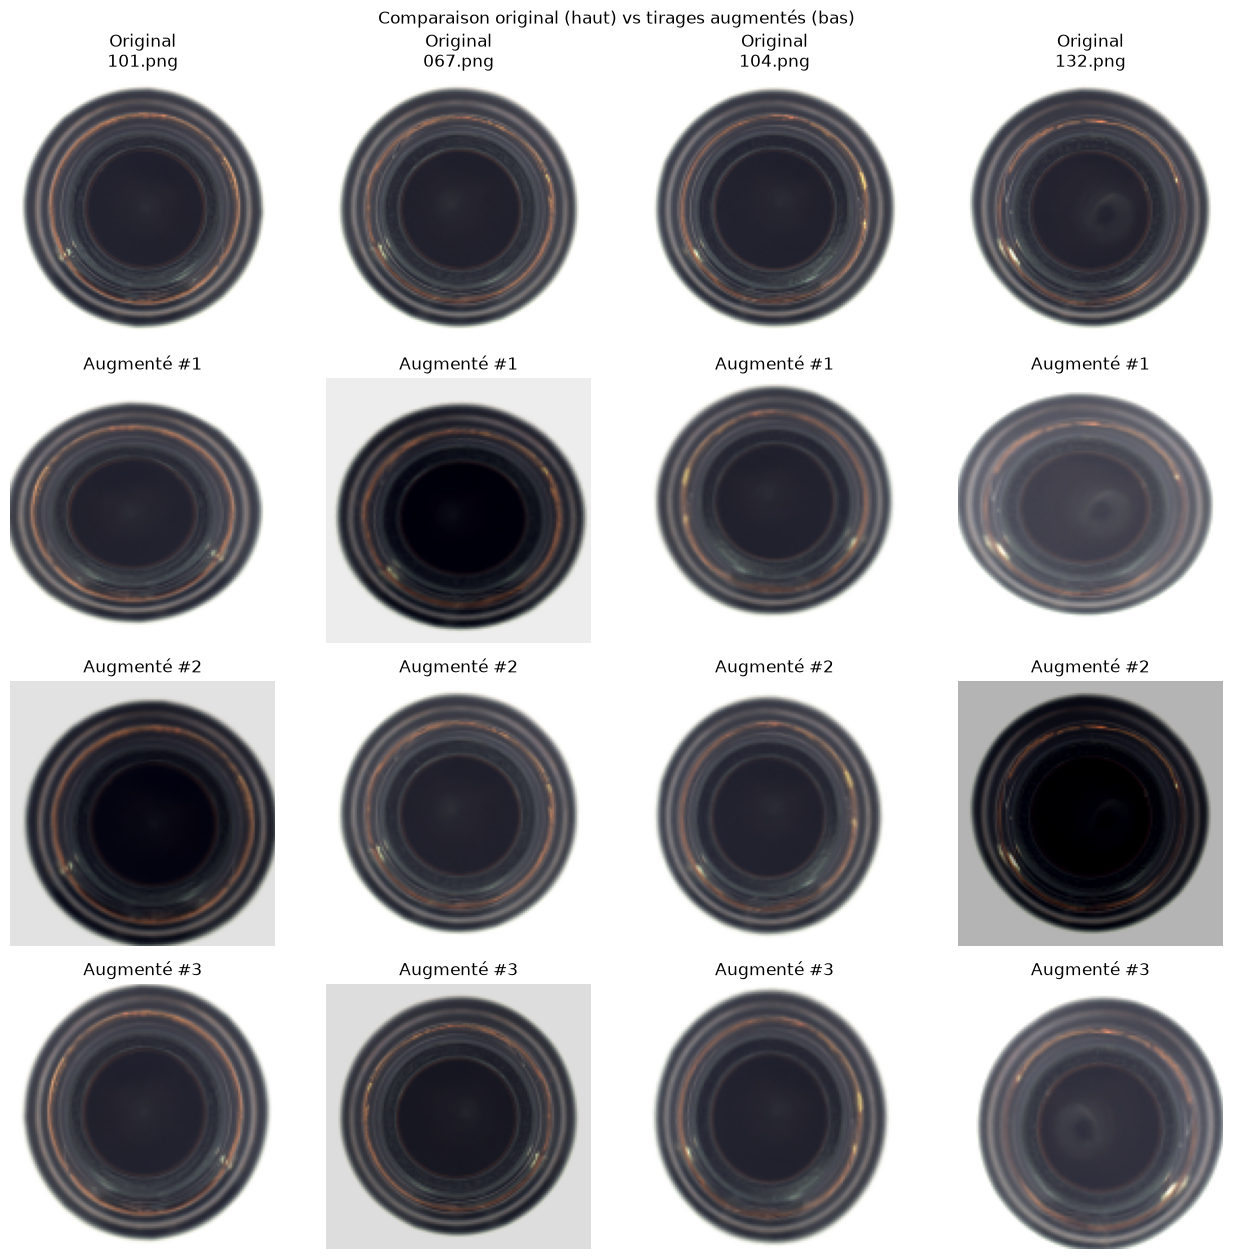

In [187]:
N_IMAGES = 4      # nombre d'images saines comparées
N_DRAWS = 3        # nombre de tirages augmentés par image

fig, axes = plt.subplots(N_DRAWS + 1, N_IMAGES, figsize=(3.2 * N_IMAGES, 3.2 * (N_DRAWS + 1)))

for col in range(N_IMAGES):
    path = train_paths[col]
    original = load_and_resize_image(path)

    axes[0, col].imshow(original)
    axes[0, col].set_title(f"Original\n{path.name}")
    axes[0, col].axis("off")

    for row in range(1, N_DRAWS + 1):
        augmented = train_transform(image=original)["image"]
        axes[row, col].imshow(augmented)
        axes[row, col].set_title(f"Augmenté #{row}")
        axes[row, col].axis("off")

plt.suptitle("Comparaison original (haut) vs tirages augmentés (bas)")
plt.tight_layout()
plt.show()

## Étape 3.8 — Vérification visuelle du chargement

Avant de construire le pipeline `tf.data`, on affiche une grille d'images chargées/redimensionnées :
- quelques images **saines** (`train/good`)
- quelques images de **chaque défaut** (`test/<defect>`), avec leur masque `ground_truth` superposé

Objectif : détecter à l'œil un souci de chargement (inversion BGR/RGB, mauvais alignement image/masque, resize qui écrase l'information) avant d'aller plus loin.

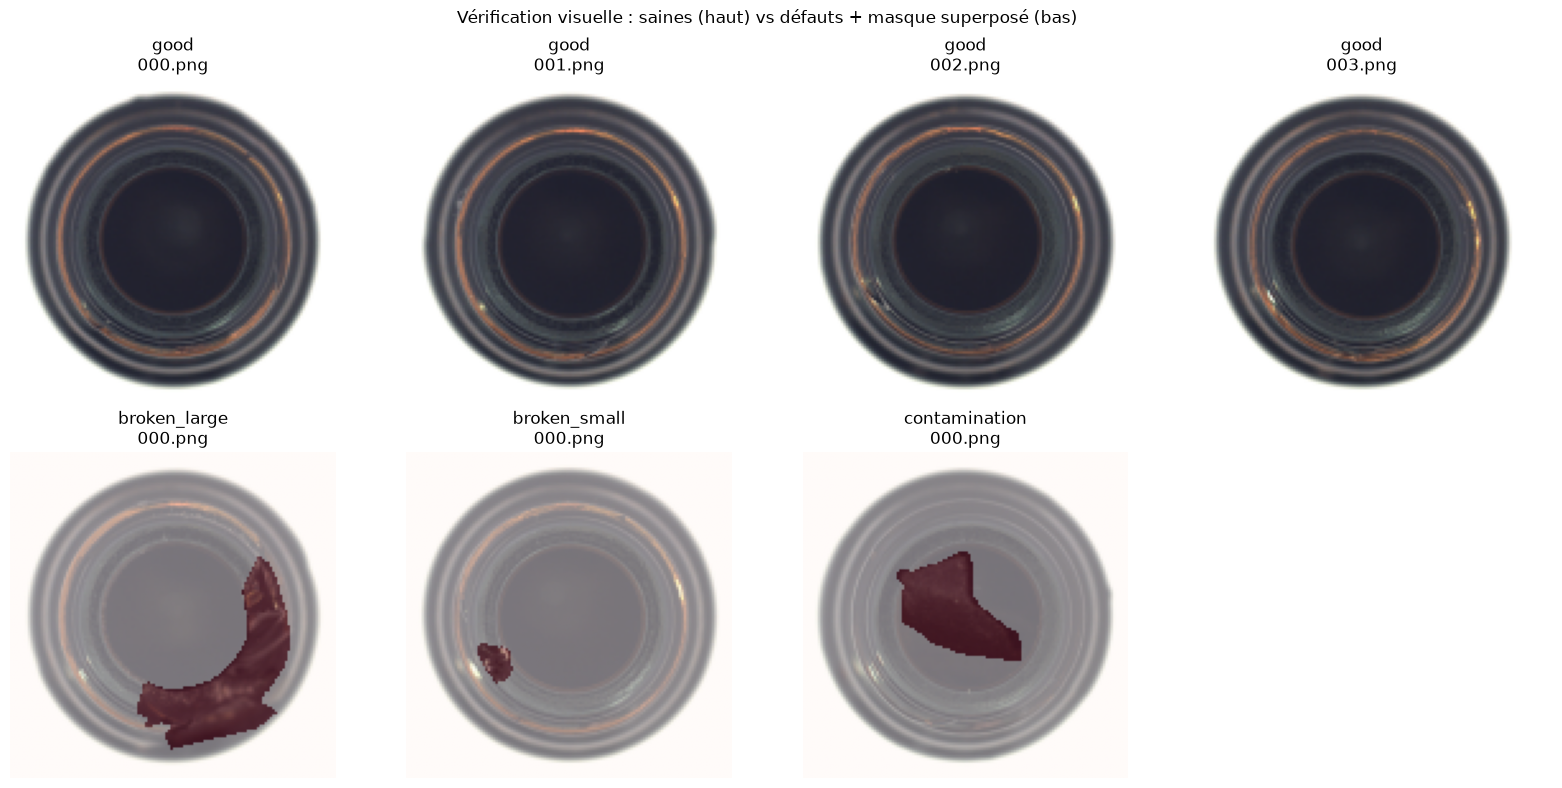

In [188]:
N_SAMPLES = 4

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(4 * N_SAMPLES, 8))

# Ligne 1 : images saines
for i, path in enumerate(train_good[:N_SAMPLES]):
    img = load_and_resize_image(path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"good\n{path.name}")
    axes[0, i].axis("off")

# Ligne 2 : un défaut par colonne (image + masque superposé)
n_defects_shown = min(N_SAMPLES, len(defect_names))
for i in range(N_SAMPLES):
    axes[1, i].axis("off")
for i, name in enumerate(defect_names[:n_defects_shown]):
    img_path = sorted((DATA_DIR / "test" / name).glob("*.png"))[0]
    mask_path = sorted((DATA_DIR / "ground_truth" / name).glob("*_mask.png"))[0]
    img = load_and_resize_image(img_path)
    mask = load_and_resize_mask(mask_path)

    axes[1, i].imshow(img)
    axes[1, i].imshow(mask, cmap="Reds", alpha=0.4)  # masque en surimpression
    axes[1, i].set_title(f"{name}\n{img_path.name}")
    axes[1, i].axis("off")

plt.suptitle("Vérification visuelle : saines (haut) vs défauts + masque superposé (bas)")
plt.tight_layout()
plt.show()

## Étape 3.9 — Construction du pipeline `tf.data` (entraînement / validation)

- `load_and_resize_image` (Pillow/OpenCV) et Albumentations ne sont pas nativement compatibles avec le graphe TensorFlow → encapsulation via `tf.py_function`.
- Augmentation appliquée uniquement si `augment=True` (train), jamais pour validation/test.
- `.cache()` optionnel si le dataset tient en mémoire (cas de `bottle`, quelques centaines d'images).

In [189]:
def make_loader(augment: bool):
    def _load(path):
        path = path.numpy().decode("utf-8")
        img = load_and_resize_image(path)
        if augment:
            img = train_transform(image=img)["image"]
        img = normalize(img)
        return img.astype(np.float32)

    def _tf_wrapper(path):
        img = tf.py_function(_load, [path], tf.float32)
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        return img
    return _tf_wrapper


def build_dataset(paths, augment=False, shuffle=False, batch_size=BATCH_SIZE, cache=True):
    paths_str = [str(p) for p in paths]
    ds = tf.data.Dataset.from_tensor_slices(paths_str)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths_str), seed=SEED)
    ds = ds.map(make_loader(augment), num_parallel_calls=tf.data.AUTOTUNE)
    if cache and not augment:
        # pas de cache si augmentation (on veut une augmentation différente à chaque epoch)
        ds = ds.cache()
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [190]:
train_ds = build_dataset(train_paths, augment=True, shuffle=True)
val_ds = build_dataset(val_paths, augment=False, shuffle=False)

for batch in train_ds.take(1):
    print("Batch shape :", batch.shape)
    print("dtype :", batch.dtype)
    print("Plage de valeurs :", float(tf.reduce_min(batch)), "-", float(tf.reduce_max(batch)))

Batch shape : (16, 128, 128, 3)
dtype : <dtype: 'float32'>
Plage de valeurs : 0.0470588244497776 - 1.0


## Étape 3.10 — Construction des datasets de test (évaluation)

- `test/good` + chaque `test/<defect>` : **pas d'augmentation**, juste resize + normalisation.
- Masques `ground_truth/<defect>` redimensionnés en parallèle pour l'évaluation pixel-level future (IoU, AUC-ROC pixel).

In [191]:
test_good_ds = build_dataset(test_good, augment=False, shuffle=False, cache=False)

test_defect_ds = {}
test_defect_masks = {}
for name in defect_names:
    imgs = sorted((DATA_DIR / "test" / name).glob("*.png"))
    masks = sorted((DATA_DIR / "ground_truth" / name).glob("*_mask.png"))
    test_defect_ds[name] = build_dataset(imgs, augment=False, shuffle=False, cache=False)
    test_defect_masks[name] = np.stack([load_and_resize_mask(m) for m in masks])
    print(f"{name}: dataset images prêt, masques shape={test_defect_masks[name].shape}")

broken_large: dataset images prêt, masques shape=(20, 128, 128)
broken_small: dataset images prêt, masques shape=(22, 128, 128)
contamination: dataset images prêt, masques shape=(21, 128, 128)


## Étape 3.11 — Étude de déséquilibre de classe

Deux niveaux à étudier, tous les deux dans `test/` (`train/good` n'a qu'une seule classe) :
- **Niveau image** : proportion saines vs défectueuses, et répartition entre types de défauts.
- **Niveau pixel** : à l'intérieur de chaque masque, fraction de pixels "défaut" vs "fond" — pertinent seulement si un modèle de segmentation est envisagé.

In [192]:
# --- Niveau image : comptage par classe ---
n_good_test = len(test_good)
n_defect_total = sum(len(v) for v in test_defect_masks.values())

print("train/good:", len(train_good))
print("test/good:", n_good_test)
for name in defect_names:
    print(f"test/{name}:", test_defect_masks[name].shape[0])

print(f"\nRatio saines/défectueuses (test) : {n_good_test}/{n_good_test + n_defect_total}"
      f" ({n_good_test/(n_good_test+n_defect_total):.1%}) vs "
      f"{n_defect_total}/{n_good_test + n_defect_total} ({n_defect_total/(n_good_test+n_defect_total):.1%})")

train/good: 209
test/good: 20
test/broken_large: 20
test/broken_small: 22
test/contamination: 21

Ratio saines/défectueuses (test) : 20/83 (24.1%) vs 63/83 (75.9%)


In [193]:
# --- Niveau pixel : fraction de pixels défectueux par masque (résolution originale) ---
pixel_fractions = {}
for name in defect_names:
    mask_paths = sorted((DATA_DIR / "ground_truth" / name).glob("*_mask.png"))
    fracs = []
    for p in mask_paths:
        m = np.array(Image.open(p).convert("L"))
        fracs.append((m > 127).sum() / m.size)
    pixel_fractions[name] = np.array(fracs)
    print(f"{name}: frac pixels défectueux — min={fracs and min(fracs):.4f} "
          f"mean={pixel_fractions[name].mean():.4f} max={pixel_fractions[name].max():.4f}")

broken_large: frac pixels défectueux — min=0.0409 mean=0.1170 max=0.2742
broken_small: frac pixels défectueux — min=0.0088 mean=0.0307 max=0.0806
contamination: frac pixels défectueux — min=0.0058 mean=0.0849 max=0.1653


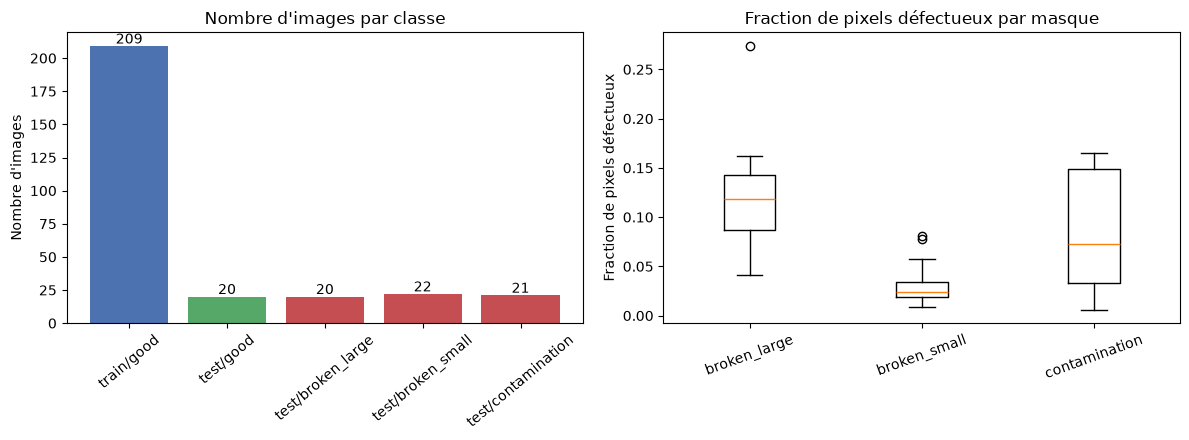

In [194]:
# --- Synthèse visuelle : comptage par classe + distribution des fractions de pixels ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

labels = ["train/good", "test/good"] + [f"test/{n}" for n in defect_names]
counts = [len(train_good), n_good_test] + [test_defect_masks[n].shape[0] for n in defect_names]
colors = ["#4C72B0", "#55A868"] + ["#C44E52"] * len(defect_names)
axes[0].bar(labels, counts, color=colors)
axes[0].set_title("Nombre d'images par classe")
axes[0].set_ylabel("Nombre d'images")
axes[0].tick_params(axis="x", rotation=40)
for i, c in enumerate(counts):
    axes[0].text(i, c + 2, str(c), ha="center")

axes[1].boxplot([pixel_fractions[n] for n in defect_names], tick_labels=defect_names)
axes[1].set_title("Fraction de pixels défectueux par masque")
axes[1].set_ylabel("Fraction de pixels défectueux")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Résumé (correspond aux sections 4 à 6 du md — arborescence, points de vigilance, prochaine étape)

| Étape (md) | Contenu | Statut |
|---|---|---|
| 3.1 | Inventaire + vérification fichiers | ✅ |
| 3.2 | Resize images ({IMG_SIZE}×{IMG_SIZE}) | ✅ |
| 3.3 | Resize masques (binaire préservé) | ✅ |
| 3.4 | Normalisation [0, 1] | ✅ |
| 3.5 | Split train/validation (images saines) | ✅ |
| 3.6 | Pipeline d'augmentation (Albumentations) | ✅ |
| 3.7 | Vérification visuelle de l'augmentation | ✅ |
| 3.8 | Vérification visuelle du chargement | ✅ |
| 3.9 | Pipeline `tf.data` (train/validation) | ✅ |
| 3.10 | Datasets de test (évaluation) | ✅ |
| 3.11 | Étude de déséquilibre de classe | ✅ |

**Prochaine étape** (section 6 du md) : définir l'architecture du modèle (autoencodeur convolutif pour la reconstruction, ou approche par extraction de features + distance type PaDiM) et le protocole d'évaluation (AUC-ROC image-level sur `test/`, IoU/AUC-ROC pixel-level via `ground_truth/`).

# Partie 2 — Autoencodeur convolutionnel (conception, entraînement, suivi MLflow)

Cette partie réutilise directement `train_ds` et `val_ds` construits à l'étape 3.9 (déjà normalisés `[0,1]`, `train_ds` avec augmentation, `val_ds` sans), ainsi que `IMG_SIZE`/`BATCH_SIZE` définis en configuration. Pas de rechargement de données ici.

In [195]:
from tensorflow.keras import layers, Model
import mlflow

## 7. Conception de l'architecture de l'autoencodeur

Un autoencodeur convolutionnel a deux moitiés symétriques :

- **Encodeur** : réduit progressivement la résolution spatiale (`strides=2`) tout en augmentant le nombre de filtres — échange l'information spatiale contre de l'information sémantique.
- **Bottleneck** : la représentation la plus compacte, au milieu du réseau — c'est la contrainte qui force le modèle à apprendre une structure du "normal" plutôt que de simplement copier l'image.
- **Décodeur** : miroir inverse (`Conv2DTranspose`), remonte en résolution jusqu'à retrouver la taille et le nombre de canaux de l'image d'origine.

**Choix de conception faits ici** :
- `strides=2` plutôt que `MaxPooling2D` : la convolution stridée apprend elle-même comment sous-échantillonner.
- Filtres qui doublent à chaque étage de l'encodeur (32→64→128→256) : compense la perte de résolution spatiale par plus de capacité de représentation.
- `padding="same"` partout : simplifie le calcul des tailles, garantit la symétrie encodeur/décodeur.
- Activation `sigmoid` en sortie : cohérente avec la normalisation `[0,1]` du pipeline (`indusense.vision.dataset.normalize`).

In [196]:
def build_autoencoder(img_size: int = IMG_SIZE, base_filters: int = 32) -> Model:
    """Autoencodeur convolutionnel symétrique.

    Encodeur : 4 Conv2D stridées (downsampling ×2 à chaque étage).
    Bottleneck : représentation (img_size/16, img_size/16, base_filters*8).
    Décodeur : 4 Conv2DTranspose stridées (upsampling ×2 à chaque étage), miroir exact de l'encodeur.
    """
    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # --- Encodeur ---
    x = layers.Conv2D(base_filters,     3, strides=2, padding="same", activation="relu", name="enc_conv1")(inputs)
    x = layers.Conv2D(base_filters * 2, 3, strides=2, padding="same", activation="relu", name="enc_conv2")(x)
    x = layers.Conv2D(base_filters * 4, 3, strides=2, padding="same", activation="relu", name="enc_conv3")(x)
    x = layers.Conv2D(base_filters * 8, 3, strides=2, padding="same", activation="relu", name="enc_conv4")(x)

    latent = x  # bottleneck

    # --- Décodeur ---
    x = layers.Conv2DTranspose(base_filters * 4, 3, strides=2, padding="same", activation="relu", name="dec_conv1")(latent)
    x = layers.Conv2DTranspose(base_filters * 2, 3, strides=2, padding="same", activation="relu", name="dec_conv2")(x)
    x = layers.Conv2DTranspose(base_filters,     3, strides=2, padding="same", activation="relu", name="dec_conv3")(x)
    outputs = layers.Conv2DTranspose(3, 3, strides=2, padding="same", activation="sigmoid", name="dec_output")(x)

    return Model(inputs, outputs, name="conv_autoencoder")


autoencoder = build_autoencoder()

### Informations clés du bottleneck

Avant de lire le `summary()` complet, on isole les informations qui caractérisent le bottleneck lui-même — c'est la partie de l'architecture qui détermine la capacité de compression du modèle, donc sa capacité à distinguer le "normal" de l'anormal.

In [197]:
bottleneck_layer_name = "enc_conv4"
bottleneck_layer = autoencoder.get_layer(bottleneck_layer_name)
bottleneck_shape = bottleneck_layer.output.shape[1:]   # (H', W', C'), sans la dimension de batch
input_shape = autoencoder.input.shape[1:]              # (H, W, C)

bottleneck_values = int(np.prod(bottleneck_shape))
input_values = int(np.prod(input_shape))
spatial_reduction = input_shape[0] // bottleneck_shape[0]   # ex. 128 // 8 = 16 (÷16 en hauteur/largeur)
compression_ratio = input_values / bottleneck_values

print(f"Couche bottleneck         : {bottleneck_layer_name}")
print(f"Forme entrée              : {tuple(input_shape)}  ({input_values} valeurs)")
print(f"Forme bottleneck          : {tuple(bottleneck_shape)}  ({bottleneck_values} valeurs)")
print(f"Réduction spatiale        : ÷{spatial_reduction} en hauteur et en largeur")
print(f"Canaux bottleneck         : {bottleneck_shape[-1]}")
print(f"Ratio de compression      : {compression_ratio:.2f}x")

Couche bottleneck         : enc_conv4
Forme entrée              : (128, 128, 3)  (49152 valeurs)
Forme bottleneck          : (8, 8, 256)  (16384 valeurs)
Réduction spatiale        : ÷16 en hauteur et en largeur
Canaux bottleneck         : 256
Ratio de compression      : 3.00x


## 8. Lecture du `summary()`

**Rappel bottleneck** (calculé en étape 7, affiché ci-dessous en évidence) : c'est `enc_conv4` qui porte le `Output Shape` le plus petit du tableau — repérer cette ligne en premier, c'est elle qui contraint toute la capacité du modèle.

Points à vérifier systématiquement dans le tableau affiché :

1. **Output Shape de la dernière couche == Output Shape de l'entrée** (`(None, 128, 128, 3)` des deux côtés) — condition nécessaire pour comparer la reconstruction à l'original pixel à pixel.
2. **Param # d'une `Conv2D`** : `(kernel_h × kernel_w × canaux_entrée + 1) × canaux_sortie` (le `+1` = biais par filtre).
3. **Symétrie du nombre de paramètres** entre encodeur et décodeur — un déséquilibre marqué signale souvent un bottleneck mal dimensionné.
4. **Total params vs volume de données** : à mettre en regard du nombre d'images d'entraînement pour anticiper un risque de sur-apprentissage.

In [198]:
print("=" * 60)
print(f"BOTTLENECK ({bottleneck_layer_name}) — à repérer dans le summary() ci-dessous")
print(f"  Forme            : {tuple(bottleneck_shape)}")
print(f"  Compression       : {input_values} -> {bottleneck_values} valeurs ({compression_ratio:.2f}x)")
print("=" * 60)

BOTTLENECK (enc_conv4) — à repérer dans le summary() ci-dessous
  Forme            : (8, 8, 256)
  Compression       : 49152 -> 16384 valeurs (3.00x)


In [199]:
autoencoder.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv4 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2DTranspose)     │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (Conv2DTranspose)    │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 776,579 (2.96 MB)

 Trainable params: 776,579 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

In [200]:
# Vérification manuelle du calcul de Param # pour les deux premières couches (formule ci-dessus)
def conv2d_params(kernel, in_channels, out_channels):
    return (kernel * kernel * in_channels + 1) * out_channels

print("enc_conv1 attendu :", conv2d_params(3, 3, 32), "  (résultat summary() : 896)")
print("enc_conv2 attendu :", conv2d_params(3, 32, 64), " (résultat summary() : 18496)")

enc_conv1 attendu : 896   (résultat summary() : 896)
enc_conv2 attendu : 18496  (résultat summary() : 18496)


### Ratio de compression

Le bottleneck ne se juge pas qu'au nombre de paramètres — ce qui compte, c'est combien de **valeurs** il faut pour représenter une image une fois passée dans l'encodeur, comparé au nombre de valeurs de l'image d'origine :

```
ratio de compression = (nb de valeurs en entrée) / (nb de valeurs dans le latent)
                      = (H × W × C entrée) / (H' × W' × C' latent)
```

Un ratio élevé (bottleneck très compact) force le modèle à apprendre une représentation plus abstraite du "normal" — utile pour la détection d'anomalie, mais risque de sous-apprentissage (reconstruction dégradée même sur des images saines) si le ratio est trop agressif. Un ratio trop faible (bottleneck presque aussi grand que l'entrée) risque à l'inverse de laisser le modèle apprendre une quasi-identité, peu informative pour distinguer sain/défectueux.

In [201]:
# Valeurs déjà calculées en étape 7 (bottleneck_shape, bottleneck_values, compression_ratio) — réaffichées ici en contexte
print(f"Entrée   : {tuple(input_shape)} -> {input_values} valeurs")
print(f"Latent   : {tuple(bottleneck_shape)} -> {bottleneck_values} valeurs")
print(f"Ratio de compression : {compression_ratio:.2f}x")

Entrée   : (128, 128, 3) -> 49152 valeurs
Latent   : (8, 8, 256) -> 16384 valeurs
Ratio de compression : 3.00x


## 9. Vérification sur un vrai batch du pipeline

In [202]:
for batch in train_ds.take(1):
    reconstruction = autoencoder(batch)
    print("Batch d'entrée :", batch.shape)
    print("Reconstruction :", reconstruction.shape)

    mse = tf.keras.losses.MeanSquaredError()
    print("MSE (poids aléatoires, avant tout entraînement) :", float(mse(batch, reconstruction)))

Batch d'entrée : (16, 128, 128, 3)
Reconstruction : (16, 128, 128, 3)
MSE (poids aléatoires, avant tout entraînement) : 0.1214609146118164


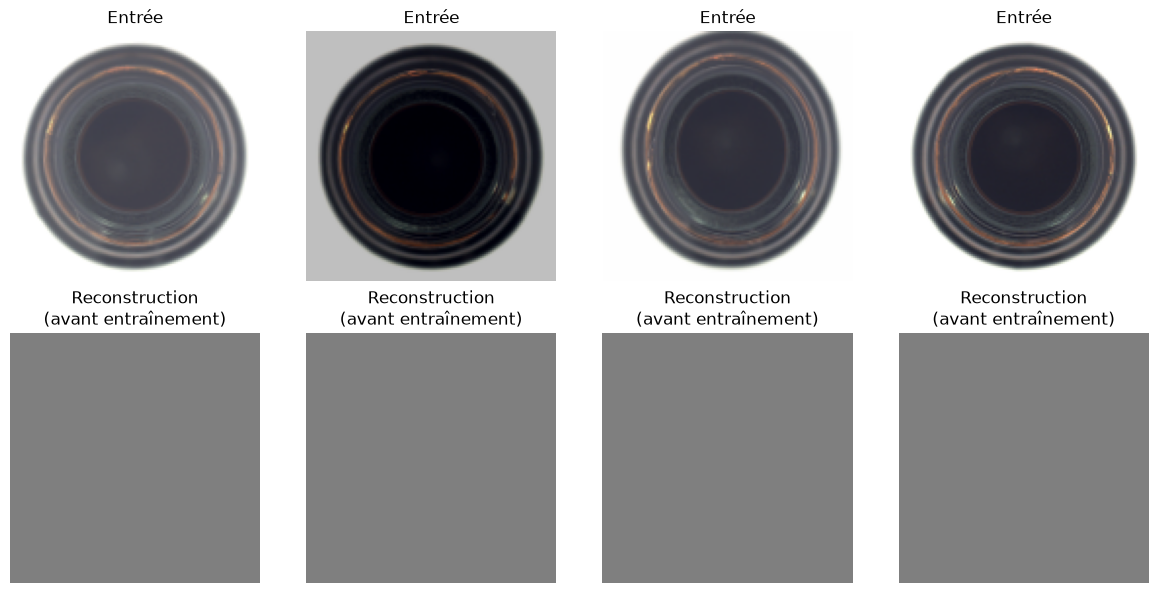

In [203]:
# Aperçu visuel : image d'entrée vs reconstruction (avant entraînement — reconstruction non informative à ce stade)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(batch[i].numpy())
    axes[0, i].set_title("Entrée")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstruction[i].numpy())
    axes[1, i].set_title("Reconstruction\n(avant entraînement)")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## 10. Deux algorithmes à comparer : perte MSE vs perte SSIM

Jusqu'ici, SSIM n'était qu'une **métrique suivie** à côté de la loss MSE (un seul modèle). Pour comprendre l'écart avant/après entraînement propre à chaque critère d'optimisation, on entraîne maintenant **deux modèles indépendants**, de même architecture (`build_autoencoder`), mais chacun optimisé sur sa propre perte :

- **Algorithme A** : `loss = MSE` (la métrique SSIM reste suivie, pour comparaison).
- **Algorithme B** : `loss = 1 - SSIM` (Keras n'a pas de loss SSIM native, on la définit explicitement ; la métrique MSE reste suivie, pour comparaison).

Les deux modèles partent de poids aléatoires indépendants, et sont évalués sur le **même batch de validation fixe** (`x_val_fixed`) avant et après entraînement — condition nécessaire pour que la comparaison "avant/après" soit valide pour chaque algorithme.

In [204]:
def ssim_metric(y_true, y_pred):
    """SSIM moyen sur le batch, en métrique de suivi (max_val=1.0 car images normalisées [0,1])."""
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
ssim_metric.__name__ = "ssim"

def ssim_loss(y_true, y_pred):
    """Perte SSIM : 1 - SSIM, minimisée quand la reconstruction est structurellement fidèle (SSIM -> 1)."""
    return 1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def mse_metric(y_true, y_pred):
    """MSE en métrique de suivi (pour le modèle entraîné avec la loss SSIM)."""
    return tf.reduce_mean(tf.square(y_true - y_pred))
mse_metric.__name__ = "mse"

train_ds_xy = train_ds.map(lambda x: (x, x))
val_ds_xy = val_ds.map(lambda x: (x, x))

# Deux instances indépendantes, mêmes hyperparamètres d'architecture
model_mse = build_autoencoder(IMG_SIZE)
model_ssim = build_autoencoder(IMG_SIZE)

# Même batch de validation fixe pour une comparaison avant/après valide sur les deux algorithmes
for batch in val_ds_xy.take(1):
    x_val_fixed, _ = batch

recon_mse_before = model_mse(x_val_fixed)
recon_ssim_before = model_ssim(x_val_fixed)

print("Reconstructions 'avant entraînement' capturées pour les deux modèles (même batch de validation, poids aléatoires).")

Reconstructions 'avant entraînement' capturées pour les deux modèles (même batch de validation, poids aléatoires).


## 11. Suivi MLflow

Même convention que le reste du projet (SQLite locale, `mlflow/mlflow.db`). **Un run MLflow distinct par algorithme** (`conv_autoencoder_mse` et `conv_autoencoder_ssim`), pour comparer les deux dans l'UI MLflow (`mlflow ui --backend-store-uri sqlite:///mlflow/mlflow.db`) :
- **Params** : `img_size`, `batch_size`, `epochs`, `early_stopping_patience`, `base_filters`, `optimizer`, `loss` (différent selon l'algorithme).
- **Metrics** par epoch : la loss native de l'algorithme (train/val) + la métrique croisée de l'autre critère (train/val), pour comparaison directe.
- **Artifacts** : courbes d'apprentissage et reconstructions avant/après, par algorithme.

In [205]:
MLFLOW_TRACKING_URI = "sqlite:///mlflow/mlflow.db"  # <- adapter si besoin (cohérent avec le reste du projet)
EXPERIMENT_NAME = "bottle_autoencoder"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

EPOCHS = 30          # nombre maximum d'epochs
PATIENCE = 5         # arrêt anticipé si val_loss ne s'améliore plus pendant PATIENCE epochs

## 12. Algorithme A — Entraînement (perte MSE)

`loss="mse"`, SSIM suivie comme métrique croisée.

In [206]:
early_stopping_mse = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=PATIENCE, restore_best_weights=True,
)

model_mse.compile(optimizer="adam", loss="mse", metrics=[ssim_metric])

with mlflow.start_run(run_name="conv_autoencoder_mse") as run_mse:
    mlflow.log_params({
        "img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "epochs": EPOCHS,
        "early_stopping_patience": PATIENCE, "base_filters": 32,
        "optimizer": "adam", "loss": "mse",
    })

    history_mse = model_mse.fit(
        train_ds_xy, validation_data=val_ds_xy,
        epochs=EPOCHS, callbacks=[early_stopping_mse], verbose=2,
    )

    epochs_trained_mse = len(history_mse.history["loss"])
    mlflow.log_param("epochs_trained", epochs_trained_mse)

    for epoch in range(epochs_trained_mse):
        mlflow.log_metrics({
            "train_loss": history_mse.history["loss"][epoch],
            "val_loss": history_mse.history["val_loss"][epoch],
            "train_ssim": history_mse.history["ssim"][epoch],
            "val_ssim": history_mse.history["val_ssim"][epoch],
        }, step=epoch)

    run_id_mse = run_mse.info.run_id

print(f"Run MLflow (MSE) terminé : {run_id_mse} — {epochs_trained_mse}/{EPOCHS} epochs effectuées.")

Epoch 1/30


e:\Projets\_workspace\aelion-4-trainning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


12/12 - 25s - 2s/step - loss: 0.1243 - ssim: 0.2977 - val_loss: 0.1144 - val_ssim: 0.2148
Epoch 2/30
12/12 - 12s - 1s/step - loss: 0.0872 - ssim: 0.2564 - val_loss: 0.0714 - val_ssim: 0.3029
Epoch 3/30
12/12 - 29s - 2s/step - loss: 0.0663 - ssim: 0.3220 - val_loss: 0.0569 - val_ssim: 0.3479
Epoch 4/30
12/12 - 24s - 2s/step - loss: 0.0528 - ssim: 0.3777 - val_loss: 0.0396 - val_ssim: 0.4415
Epoch 5/30
12/12 - 23s - 2s/step - loss: 0.0388 - ssim: 0.3545 - val_loss: 0.0224 - val_ssim: 0.3454
Epoch 6/30
12/12 - 19s - 2s/step - loss: 0.0189 - ssim: 0.3187 - val_loss: 0.0097 - val_ssim: 0.3490
Epoch 7/30
12/12 - 20s - 2s/step - loss: 0.0092 - ssim: 0.3871 - val_loss: 0.0062 - val_ssim: 0.4361
Epoch 8/30
12/12 - 14s - 1s/step - loss: 0.0069 - ssim: 0.4742 - val_loss: 0.0062 - val_ssim: 0.5068
Epoch 9/30
12/12 - 9s - 724ms/step - loss: 0.0059 - ssim: 0.5632 - val_loss: 0.0045 - val_ssim: 0.5937
Epoch 10/30
12/12 - 8s - 697ms/step - loss: 0.0054 - ssim: 0.6050 - val_loss: 0.0038 - val_ssim: 0.6

## 13. Algorithme A — Courbes d'apprentissage (MSE)

- **Loss (MSE)** : doit décroître sur train et validation.
- **SSIM (métrique croisée)** : doit croître vers 1.0 — permet de voir si optimiser directement le MSE améliore aussi la similarité structurelle, ou si les deux critères divergent.

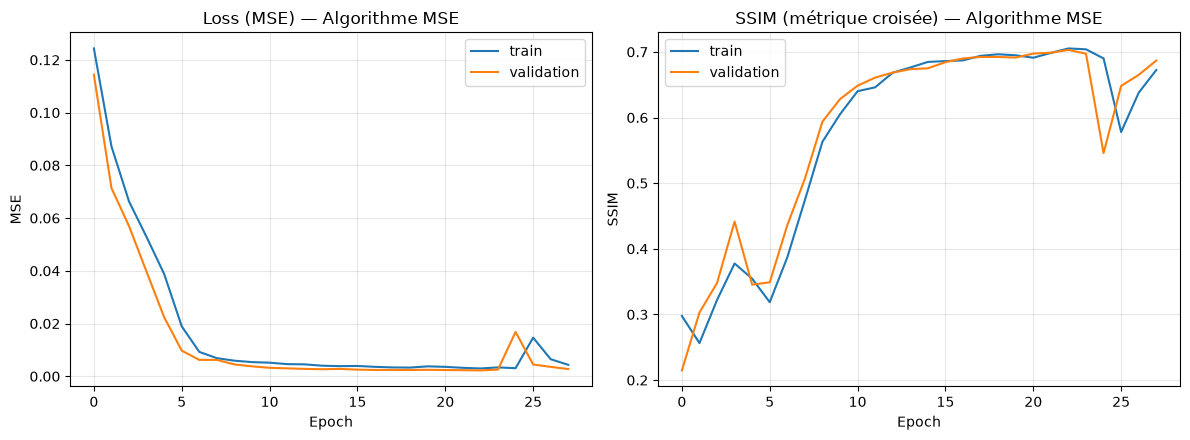

In [207]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_mse.history["loss"], label="train")
axes[0].plot(history_mse.history["val_loss"], label="validation")
axes[0].set_title("Loss (MSE) — Algorithme MSE")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_mse.history["ssim"], label="train")
axes[1].plot(history_mse.history["val_ssim"], label="validation")
axes[1].set_title("SSIM (métrique croisée) — Algorithme MSE")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("SSIM"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()

with mlflow.start_run(run_id=run_id_mse):
    mlflow.log_figure(fig, f"curves_{run_id_mse}.png")

plt.show()

## 14. Algorithme A — Reconstruction avant / après entraînement

Même batch de validation (`x_val_fixed`) que la capture "avant entraînement" de la section 10 — comparaison directe de l'écart apporté par l'entraînement sur la perte MSE.

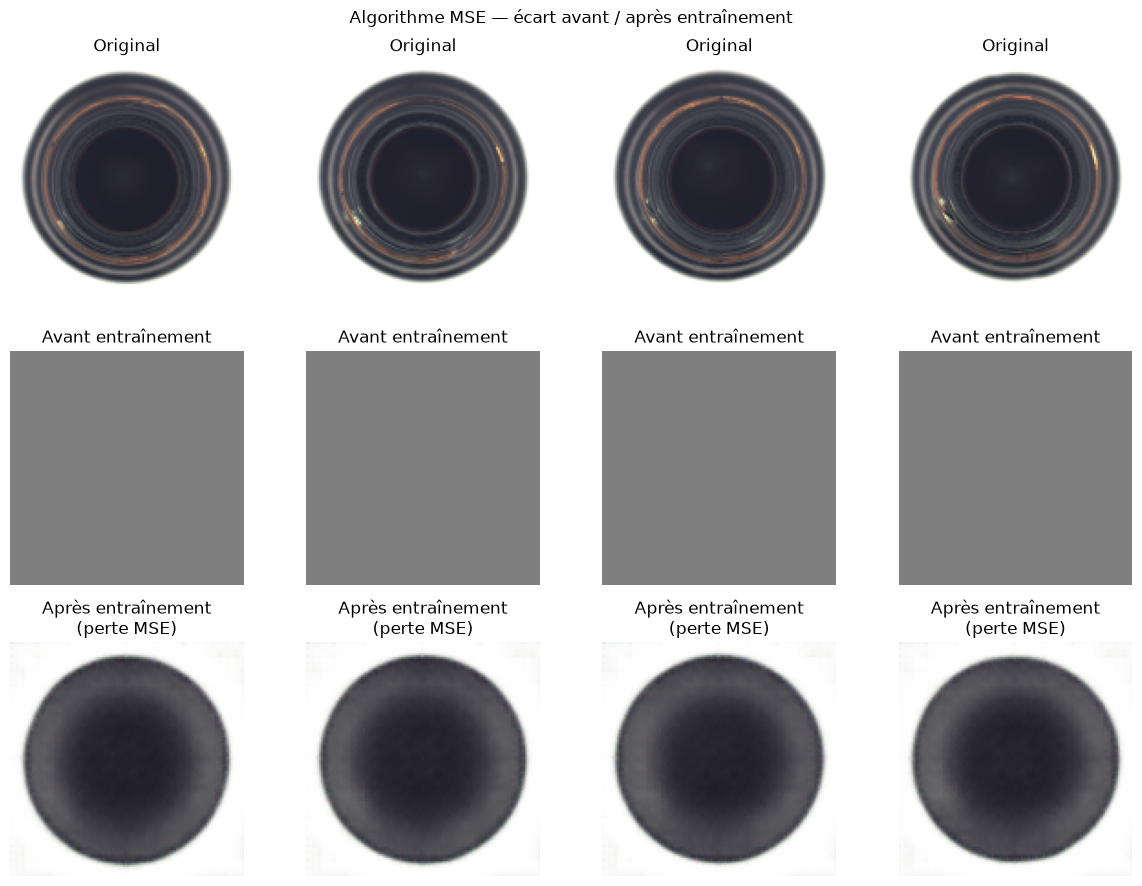

In [208]:
recon_mse_after = model_mse(x_val_fixed)

n_show = min(4, x_val_fixed.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))
for i in range(n_show):
    axes[0, i].imshow(x_val_fixed[i].numpy()); axes[0, i].set_title("Original"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_mse_before[i].numpy()); axes[1, i].set_title("Avant entraînement"); axes[1, i].axis("off")
    axes[2, i].imshow(recon_mse_after[i].numpy()); axes[2, i].set_title("Après entraînement\n(perte MSE)"); axes[2, i].axis("off")
plt.suptitle("Algorithme MSE — écart avant / après entraînement")
plt.tight_layout()

with mlflow.start_run(run_id=run_id_mse):
    mlflow.log_figure(fig, f"reconstructions_before_after_{run_id_mse}.png")

plt.show()

## 15. Algorithme B — Entraînement (perte SSIM)

`loss=ssim_loss` (1 - SSIM), MSE suivie comme métrique croisée. Même `EPOCHS`/`PATIENCE` que l'algorithme A, pour une comparaison équitable.

In [209]:
early_stopping_ssim = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=PATIENCE, restore_best_weights=True,
)

model_ssim.compile(optimizer="adam", loss=ssim_loss, metrics=[mse_metric])

with mlflow.start_run(run_name="conv_autoencoder_ssim") as run_ssim:
    mlflow.log_params({
        "img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "epochs": EPOCHS,
        "early_stopping_patience": PATIENCE, "base_filters": 32,
        "optimizer": "adam", "loss": "ssim_loss (1 - SSIM)",
    })

    history_ssim = model_ssim.fit(
        train_ds_xy, validation_data=val_ds_xy,
        epochs=EPOCHS, callbacks=[early_stopping_ssim], verbose=2,
    )

    epochs_trained_ssim = len(history_ssim.history["loss"])
    mlflow.log_param("epochs_trained", epochs_trained_ssim)

    for epoch in range(epochs_trained_ssim):
        mlflow.log_metrics({
            "train_loss": history_ssim.history["loss"][epoch],
            "val_loss": history_ssim.history["val_loss"][epoch],
            "train_mse": history_ssim.history["mse"][epoch],
            "val_mse": history_ssim.history["val_mse"][epoch],
        }, step=epoch)

    run_id_ssim = run_ssim.info.run_id

print(f"Run MLflow (SSIM) terminé : {run_id_ssim} — {epochs_trained_ssim}/{EPOCHS} epochs effectuées.")

Epoch 1/30
12/12 - 79s - 7s/step - loss: 0.6213 - mse: 0.1268 - val_loss: 0.6410 - val_mse: 0.1310
Epoch 2/30
12/12 - 41s - 3s/step - loss: 0.6208 - mse: 0.1225 - val_loss: 0.6226 - val_mse: 0.1284
Epoch 3/30
12/12 - 28s - 2s/step - loss: 0.5990 - mse: 0.1189 - val_loss: 0.5446 - val_mse: 0.1117
Epoch 4/30
12/12 - 33s - 3s/step - loss: 0.5312 - mse: 0.0904 - val_loss: 0.4272 - val_mse: 0.0700
Epoch 5/30
12/12 - 32s - 3s/step - loss: 0.4349 - mse: 0.0521 - val_loss: 0.3423 - val_mse: 0.0328
Epoch 6/30
12/12 - 56s - 5s/step - loss: 0.3653 - mse: 0.0239 - val_loss: 0.2904 - val_mse: 0.0189
Epoch 7/30
12/12 - 26s - 2s/step - loss: 0.3073 - mse: 0.0161 - val_loss: 0.2014 - val_mse: 0.0067
Epoch 8/30
12/12 - 34s - 3s/step - loss: 0.2494 - mse: 0.0086 - val_loss: 0.1904 - val_mse: 0.0079
Epoch 9/30
12/12 - 23s - 2s/step - loss: 0.2252 - mse: 0.0066 - val_loss: 0.1651 - val_mse: 0.0036
Epoch 10/30
12/12 - 26s - 2s/step - loss: 0.1901 - mse: 0.0048 - val_loss: 0.1660 - val_mse: 0.0037
Epoch 11/

## 16. Algorithme B — Courbes d'apprentissage (SSIM)

- **Loss (1 - SSIM)** : doit décroître (donc SSIM croît vers 1.0) sur train et validation.
- **MSE (métrique croisée)** : à surveiller — optimiser SSIM ne garantit pas de minimiser le MSE, les deux courbes peuvent diverger, c'est justement ce que cette comparaison doit révéler.

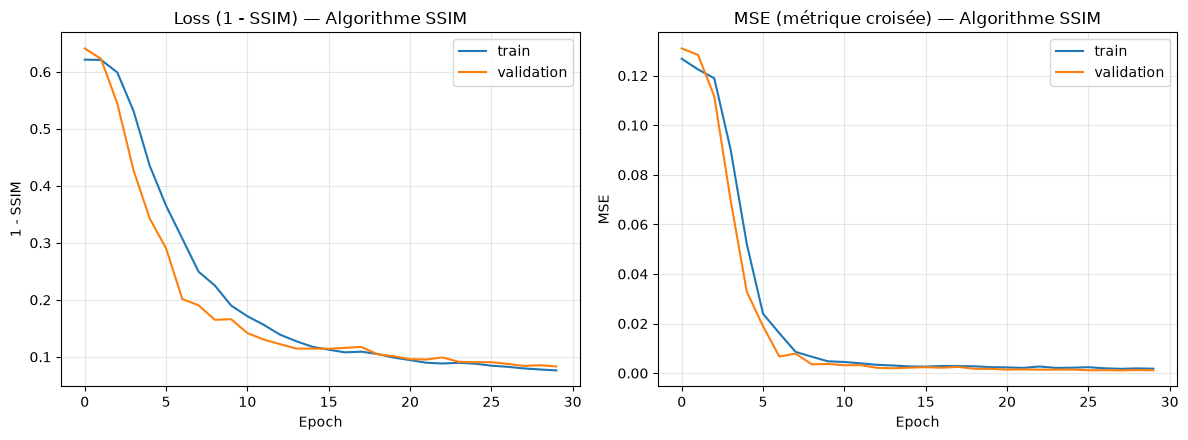

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_ssim.history["loss"], label="train")
axes[0].plot(history_ssim.history["val_loss"], label="validation")
axes[0].set_title("Loss (1 - SSIM) — Algorithme SSIM")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("1 - SSIM"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_ssim.history["mse"], label="train")
axes[1].plot(history_ssim.history["val_mse"], label="validation")
axes[1].set_title("MSE (métrique croisée) — Algorithme SSIM")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()

with mlflow.start_run(run_id=run_id_ssim):
    mlflow.log_figure(fig, f"curves_{run_id_ssim}.png")

plt.show()

## 17. Algorithme B — Reconstruction avant / après entraînement

Même batch de validation fixe, même mise en page que pour l'algorithme A (section 14) — comparaison directe possible entre les deux algorithmes (section 18).

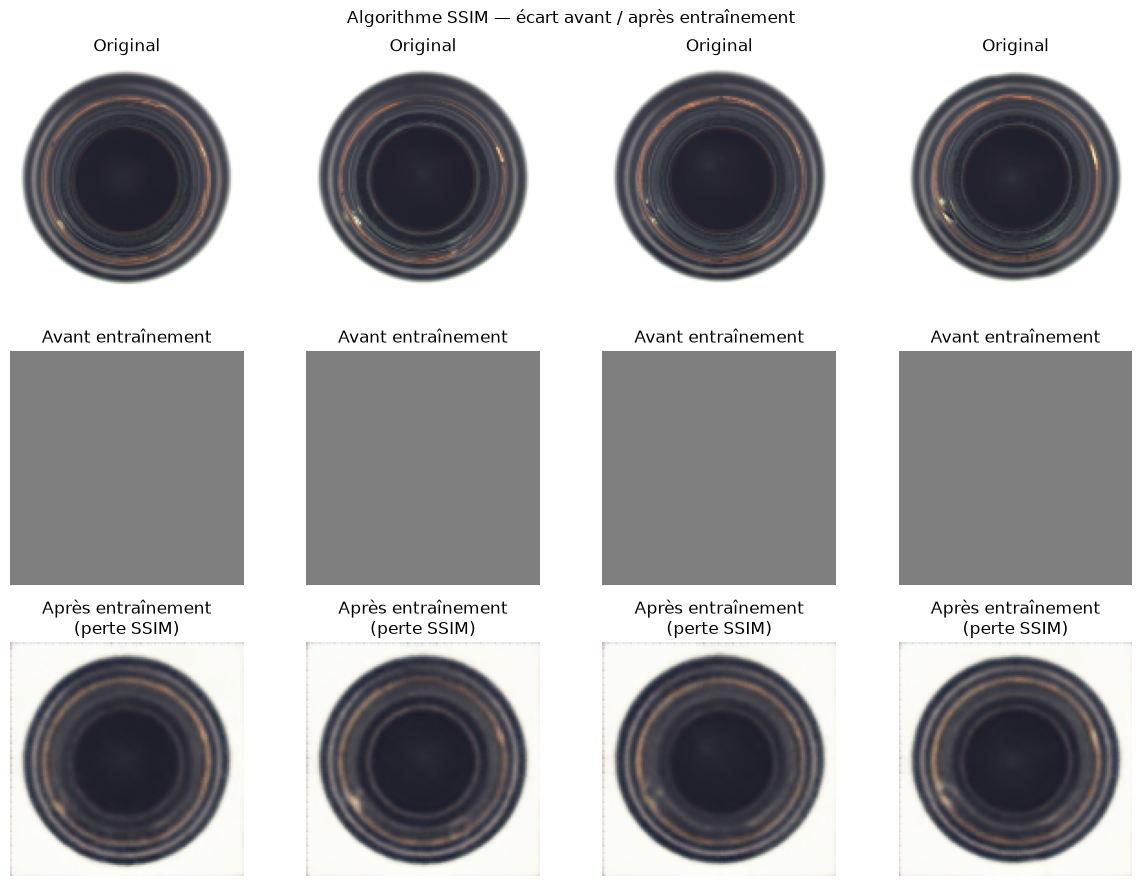

In [211]:
recon_ssim_after = model_ssim(x_val_fixed)

n_show = min(4, x_val_fixed.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))
for i in range(n_show):
    axes[0, i].imshow(x_val_fixed[i].numpy()); axes[0, i].set_title("Original"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_ssim_before[i].numpy()); axes[1, i].set_title("Avant entraînement"); axes[1, i].axis("off")
    axes[2, i].imshow(recon_ssim_after[i].numpy()); axes[2, i].set_title("Après entraînement\n(perte SSIM)"); axes[2, i].axis("off")
plt.suptitle("Algorithme SSIM — écart avant / après entraînement")
plt.tight_layout()

with mlflow.start_run(run_id=run_id_ssim):
    mlflow.log_figure(fig, f"reconstructions_before_after_{run_id_ssim}.png")

plt.show()

## 18. Comparaison des deux algorithmes

Les deux modèles reconstruisent les **mêmes images de validation** — comparaison directe de l'effet du choix de la loss sur la qualité perçue de la reconstruction, et sur les métriques finales.

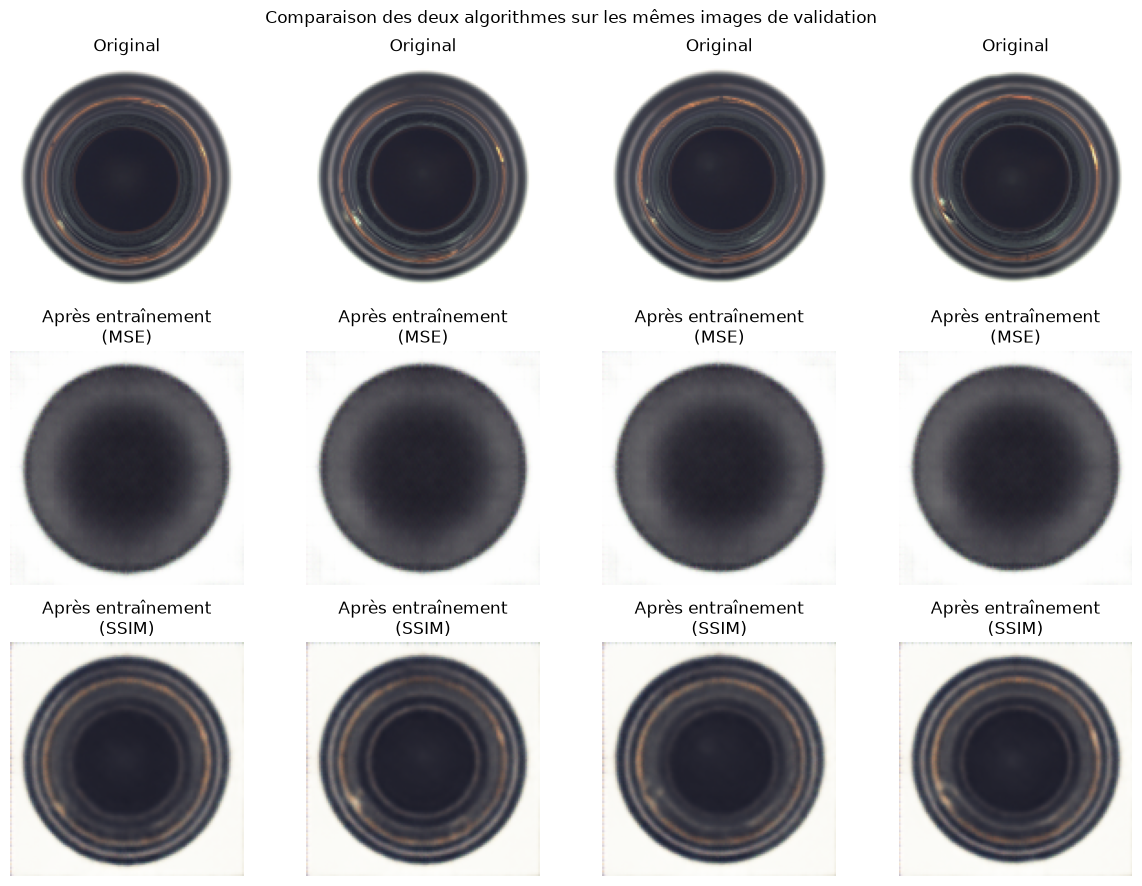

Résumé final :
  MSE  — 28 epochs — val_loss(MSE)=0.00274 — val_ssim=0.6868
  SSIM — 30 epochs — val_loss(1-SSIM)=0.08315 — val_mse=0.00113


In [212]:
n_show = min(4, x_val_fixed.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))
for i in range(n_show):
    axes[0, i].imshow(x_val_fixed[i].numpy()); axes[0, i].set_title("Original"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_mse_after[i].numpy()); axes[1, i].set_title("Après entraînement\n(MSE)"); axes[1, i].axis("off")
    axes[2, i].imshow(recon_ssim_after[i].numpy()); axes[2, i].set_title("Après entraînement\n(SSIM)"); axes[2, i].axis("off")
plt.suptitle("Comparaison des deux algorithmes sur les mêmes images de validation")
plt.tight_layout()
plt.show()

print("Résumé final :")
print(f"  MSE  — {epochs_trained_mse} epochs — val_loss(MSE)={history_mse.history['val_loss'][-1]:.5f} — val_ssim={history_mse.history['val_ssim'][-1]:.4f}")
print(f"  SSIM — {epochs_trained_ssim} epochs — val_loss(1-SSIM)={history_ssim.history['val_loss'][-1]:.5f} — val_mse={history_ssim.history['val_mse'][-1]:.5f}")

## 19. Score d'anomalie et calibration du seuil (comparaison MSE vs SSIM)

Même principe que précédemment (score = erreur de reconstruction MSE par image, seuil calibré uniquement sur `val_ds`), appliqué **séparément aux deux modèles entraînés**, pour voir si le choix de la loss d'entraînement change la capacité de discrimination saines/défauts du score d'anomalie.

Deux critères de calibration du seuil, calculés en parallèle :
- **Percentile** (p95 des scores de validation) : ne fait aucune hypothèse sur la forme de la distribution, mais sensible au bruit d'échantillonnage sur un petit `val_ds`.
- **Moyenne + k·écart-type** (k=3, règle "3-sigma") : suppose une distribution à peu près symétrique/gaussienne des scores sains, mais plus stable si la distribution est bien comportée — et peut réagir différemment en présence de quelques valeurs extrêmes (un score très élevé peut à lui seul gonfler l'écart-type et donc remonter ce seuil, alors que le percentile y est plus robuste).

In [213]:
def reconstruction_errors(dataset, model):
    """Erreur de reconstruction (MSE) par image — un score par image, pas par batch."""
    errors = []
    for batch in dataset:
        recon = model(batch)
        err = tf.reduce_mean(tf.square(batch - recon), axis=[1, 2, 3])
        errors.append(err.numpy())
    return np.concatenate(errors)

THRESHOLD_PERCENTILE = 95
K_STD = 3  # seuil = moyenne + K_STD écarts-types (règle "3-sigma", classique en détection d'anomalie)

models = {"MSE": (model_mse, run_id_mse), "SSIM": (model_ssim, run_id_ssim)}
scores, thresholds, recalls, fprs = {}, {}, {}, {}
thresholds_std, recalls_std, fprs_std = {}, {}, {}

for name, (model, rid) in models.items():
    val_scores = reconstruction_errors(val_ds, model)
    test_good_scores = reconstruction_errors(test_good_ds, model)
    test_defect_scores = np.concatenate([reconstruction_errors(ds, model) for ds in test_defect_ds.values()])

    # Critère 1 : percentile des scores de validation saines
    threshold = np.percentile(val_scores, THRESHOLD_PERCENTILE)
    recall = (test_defect_scores > threshold).mean()
    fpr = (test_good_scores > threshold).mean()

    # Critère 2 : moyenne + K_STD écarts-types des scores de validation saines
    threshold_std = val_scores.mean() + K_STD * val_scores.std()
    recall_std = (test_defect_scores > threshold_std).mean()
    fpr_std = (test_good_scores > threshold_std).mean()

    scores[name] = {"val": val_scores, "good": test_good_scores, "defect": test_defect_scores}
    thresholds[name], recalls[name], fprs[name] = threshold, recall, fpr
    thresholds_std[name], recalls_std[name], fprs_std[name] = threshold_std, recall_std, fpr_std

    with mlflow.start_run(run_id=rid):
        mlflow.log_metrics({
            "threshold_p95": threshold, "recall_p95": recall, "fpr_p95": fpr,
            "threshold_mean_kstd": threshold_std, "recall_mean_kstd": recall_std, "fpr_mean_kstd": fpr_std,
        })

    print(f"[{name}] seuil percentile (p{THRESHOLD_PERCENTILE}) = {threshold:.5f}  "
          f"rappel={recall:.2%}  faux positifs={fpr:.2%}")
    print(f"[{name}] seuil moyenne+{K_STD}·std        = {threshold_std:.5f}  "
          f"rappel={recall_std:.2%}  faux positifs={fpr_std:.2%}")

[MSE] seuil percentile (p95) = 0.00263  rappel=58.73%  faux positifs=35.00%
[MSE] seuil moyenne+3·std        = 0.00295  rappel=42.86%  faux positifs=5.00%
[SSIM] seuil percentile (p95) = 0.00131  rappel=55.56%  faux positifs=10.00%
[SSIM] seuil moyenne+3·std        = 0.00142  rappel=38.10%  faux positifs=5.00%


### Vérification de la généralisation du seuil : `val` vs `test/good`

Le seuil est calibré sur `val_scores` (saines de validation) puis appliqué à `test_good_scores` (saines de test) et `test_defect_scores`. Pour que ça marche, il faut que **`val_scores` et `test_good_scores` suivent une distribution similaire** — ce sont deux échantillons de la même population ("images saines"), juste des images différentes.

Si les deux distributions diffèrent nettement (décalage, forme différente), le seuil calibré sur `val` ne se généralise pas bien à `test/good` — c'est très probablement ce qui explique le taux de faux positifs élevé et instable observé pour l'algorithme MSE (35-40 % de FP au lieu des ~5 % visés), contre un algorithme SSIM qui reste proche de sa cible.

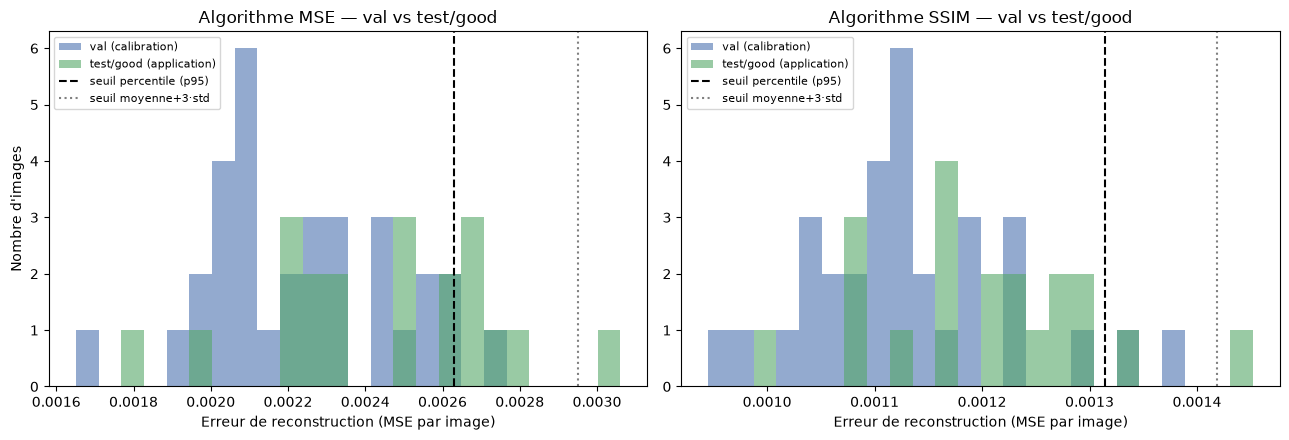

[MSE] mean(val)=0.00223  mean(test/good)=0.00245  écart=+9.7%
        p95(val)=0.00263  p95(test/good)=0.00280
[SSIM] mean(val)=0.00113  mean(test/good)=0.00120  écart=+6.3%
        p95(val)=0.00131  p95(test/good)=0.00134


In [214]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name in zip(axes, ["MSE", "SSIM"]):
    val_s, good_s = scores[name]["val"], scores[name]["good"]
    threshold, threshold_std = thresholds[name], thresholds_std[name]
    bins = np.linspace(min(val_s.min(), good_s.min()), max(val_s.max(), good_s.max()), 25)
    ax.hist(val_s, bins=bins, alpha=0.6, label="val (calibration)", color="#4C72B0")
    ax.hist(good_s, bins=bins, alpha=0.6, label="test/good (application)", color="#55A868")
    ax.axvline(threshold, color="black", linestyle="--", label=f"seuil percentile (p{THRESHOLD_PERCENTILE})")
    ax.axvline(threshold_std, color="gray", linestyle=":", label=f"seuil moyenne+{K_STD}·std")
    ax.set_title(f"Algorithme {name} — val vs test/good")
    ax.set_xlabel("Erreur de reconstruction (MSE par image)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Nombre d'images")
plt.tight_layout()

with mlflow.start_run(run_id=run_id_mse):
    mlflow.log_figure(fig, f"val_vs_test_good_{run_id_mse}.png")

plt.show()

# Écart quantifié entre les deux distributions (moyenne et p95), par algorithme
for name in ["MSE", "SSIM"]:
    val_s, good_s = scores[name]["val"], scores[name]["good"]
    print(f"[{name}] mean(val)={val_s.mean():.5f}  mean(test/good)={good_s.mean():.5f}  "
          f"écart={100*(good_s.mean()-val_s.mean())/val_s.mean():+.1f}%")
    print(f"        p95(val)={np.percentile(val_s,95):.5f}  p95(test/good)={np.percentile(good_s,95):.5f}")

### Rendu visuel — histogrammes saines vs défauts, un panneau par algorithme

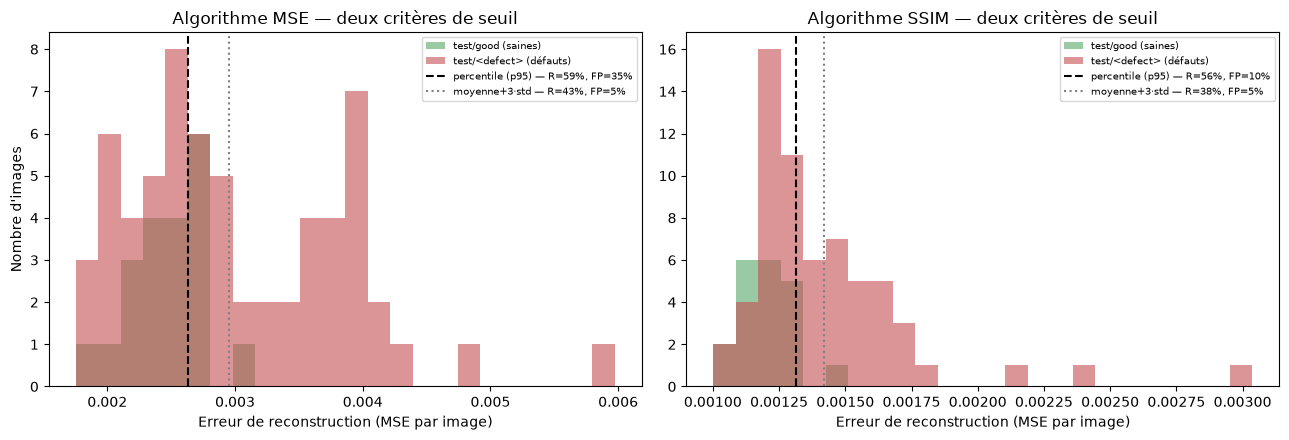

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name in zip(axes, ["MSE", "SSIM"]):
    good, defect = scores[name]["good"], scores[name]["defect"]
    threshold, threshold_std = thresholds[name], thresholds_std[name]
    bins = np.linspace(min(good.min(), defect.min()), max(good.max(), defect.max()), 25)
    ax.hist(good, bins=bins, alpha=0.6, label="test/good (saines)", color="#55A868")
    ax.hist(defect, bins=bins, alpha=0.6, label="test/<defect> (défauts)", color="#C44E52")
    ax.axvline(threshold, color="black", linestyle="--",
               label=f"percentile (p{THRESHOLD_PERCENTILE}) — R={recalls[name]:.0%}, FP={fprs[name]:.0%}")
    ax.axvline(threshold_std, color="gray", linestyle=":",
               label=f"moyenne+{K_STD}·std — R={recalls_std[name]:.0%}, FP={fprs_std[name]:.0%}")
    ax.set_title(f"Algorithme {name} — deux critères de seuil")
    ax.set_xlabel("Erreur de reconstruction (MSE par image)")
    ax.legend(fontsize=7)
axes[0].set_ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

### Abaisser le seuil augmente le rappel — comparaison des deux algorithmes

Rendu distinct : rappel et taux de faux positifs en fonction du seuil (balayage de percentiles), une courbe par algorithme — permet de voir directement si un algorithme offre un meilleur compromis rappel/faux-positifs que l'autre, à n'importe quel seuil.

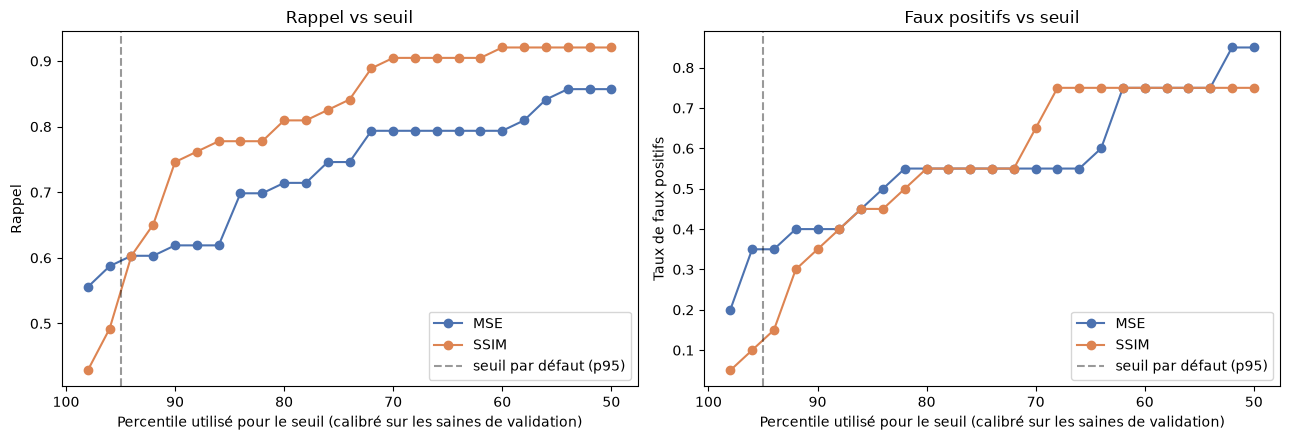

In [216]:
percentiles = np.arange(50, 100, 2)
threshold_sweep = {}  # stocké pour réutilisation (ajustement du percentile en étape finale, sans recalcul)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, color in [("MSE", "#4C72B0"), ("SSIM", "#DD8452")]:
    val_scores, good, defect = scores[name]["val"], scores[name]["good"], scores[name]["defect"]
    recall_curve = np.array([(defect > np.percentile(val_scores, p)).mean() for p in percentiles])
    fpr_curve = np.array([(good > np.percentile(val_scores, p)).mean() for p in percentiles])
    threshold_sweep[name] = {"percentiles": percentiles, "recall": recall_curve, "fpr": fpr_curve}
    axes[0].plot(percentiles, recall_curve, marker="o", label=f"{name}", color=color)
    axes[1].plot(percentiles, fpr_curve, marker="o", label=f"{name}", color=color)

for ax, title in zip(axes, ["Rappel vs seuil", "Faux positifs vs seuil"]):
    ax.axvline(THRESHOLD_PERCENTILE, color="black", linestyle="--", alpha=0.4, label=f"seuil par défaut (p{THRESHOLD_PERCENTILE})")
    ax.set_xlabel("Percentile utilisé pour le seuil (calibré sur les saines de validation)")
    ax.set_title(title)
    ax.invert_xaxis()
    ax.legend()
axes[0].set_ylabel("Rappel")
axes[1].set_ylabel("Taux de faux positifs")
plt.tight_layout()

with mlflow.start_run(run_id=run_id_mse):
    mlflow.log_figure(fig, f"recall_vs_threshold_comparison_{run_id_mse}.png")

plt.show()

**Lecture** : pour les deux algorithmes, le rappel augmente quand on abaisse le seuil, au prix de plus de faux positifs — pas de seuil "gratuit". Si une courbe domine l'autre (meilleur rappel pour un même taux de faux positifs), l'algorithme correspondant offre un meilleur score d'anomalie intrinsèque. Le choix final du seuil dépend ensuite du coût métier relatif d'un défaut manqué vs d'une fausse alerte (cf. `etude_desequilibre_classe.md`).

## 21. Heatmaps & évaluation

Jusqu'ici le score d'anomalie était un scalaire par image (MSE moyenne sur toute l'image). Cette section descend au niveau pixel : **carte d'erreur** (heatmap) pour localiser visuellement le défaut, puis évaluation quantitative à deux échelles — **image-level** (l'image est-elle anormale ?) et **pixel-level** (où est l'anomalie ?), en s'appuyant sur les masques `ground_truth`.

### Carte d'erreur par pixel (heatmap)

La heatmap est la version **non agrégée** du score d'anomalie : au lieu de moyenner l'erreur quadratique sur toute l'image (un seul chiffre), on la garde par pixel — chaque pixel de la carte indique à quel point sa reconstruction diffère de l'original. Rendu : `original | reconstruction | heatmap | masque ground-truth`, un exemple par classe de défaut, pour chaque algorithme.

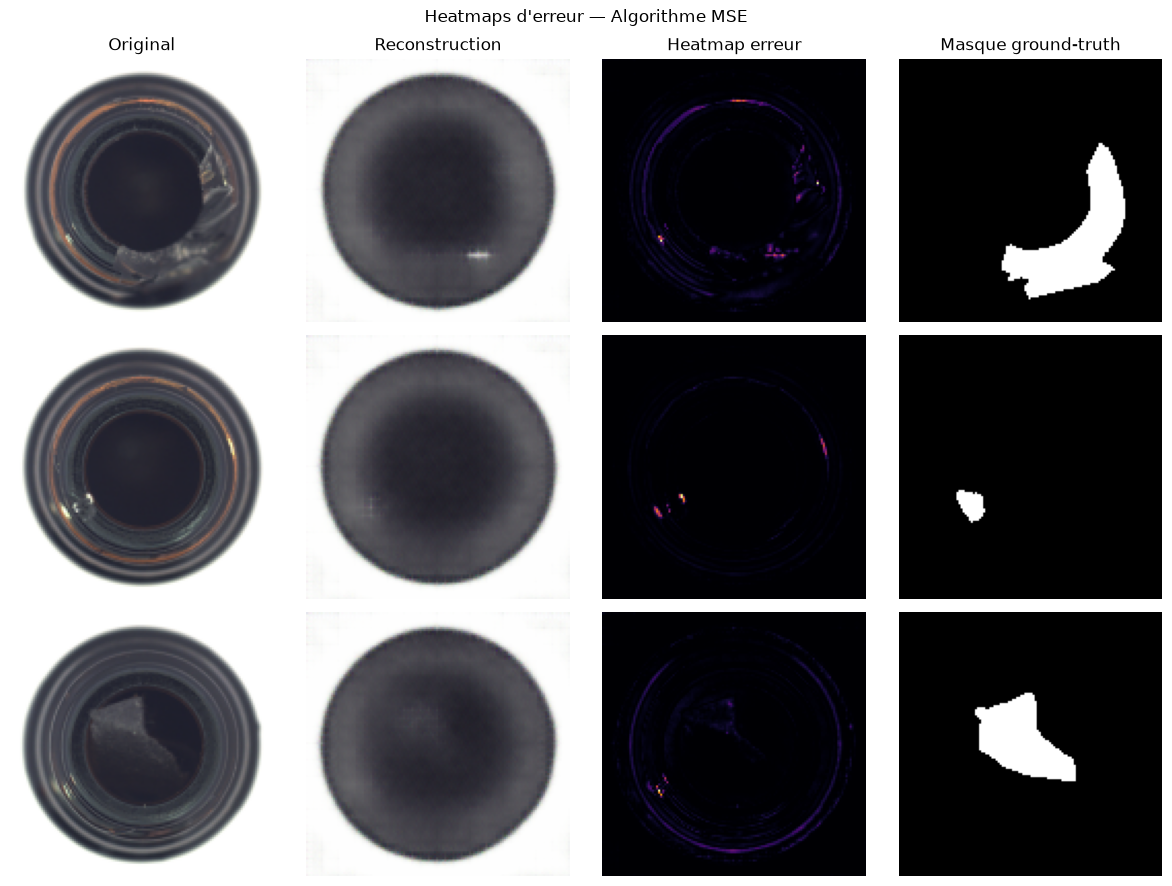

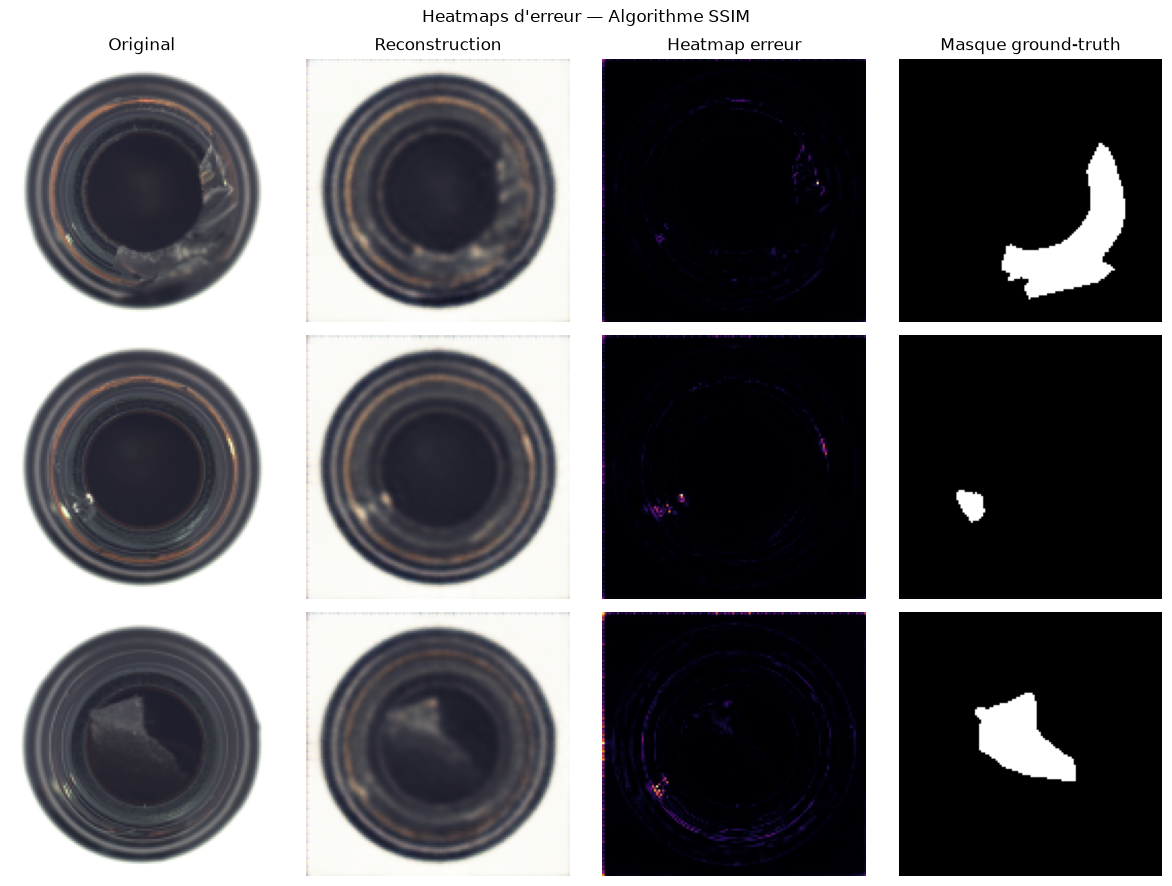

In [217]:
def error_heatmap(original, reconstruction):
    """Carte d'erreur par pixel : moyenne du carré de l'écart sur les canaux -> (H, W)."""
    return tf.reduce_mean(tf.square(original - reconstruction), axis=-1)


def plot_heatmap_grid(model, model_name):
    """Grille original / reconstruction / heatmap / masque, un exemple par classe de défaut."""
    examples = []
    for name in defect_names:
        batch = next(iter(test_defect_ds[name]))
        img = batch[0]
        mask = test_defect_masks[name][0]
        recon = model(tf.expand_dims(img, 0))[0]
        heatmap = error_heatmap(img, recon).numpy()
        examples.append((name, img.numpy(), recon.numpy(), heatmap, mask))

    fig, axes = plt.subplots(len(examples), 4, figsize=(12, 3 * len(examples)))
    col_titles = ["Original", "Reconstruction", "Heatmap erreur", "Masque ground-truth"]
    for row, (name, img, recon, heatmap, mask) in enumerate(examples):
        axes[row, 0].imshow(img); axes[row, 0].axis("off")
        axes[row, 1].imshow(recon); axes[row, 1].axis("off")
        axes[row, 2].imshow(heatmap, cmap="inferno"); axes[row, 2].axis("off")
        axes[row, 3].imshow(mask, cmap="gray"); axes[row, 3].axis("off")
        axes[row, 0].set_ylabel(name, fontsize=9)
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title)
    plt.suptitle(f"Heatmaps d'erreur — Algorithme {model_name}")
    plt.tight_layout()
    return fig


fig_heatmap_mse = plot_heatmap_grid(model_mse, "MSE")
with mlflow.start_run(run_id=run_id_mse):
    mlflow.log_figure(fig_heatmap_mse, f"heatmaps_{run_id_mse}.png")
plt.show()

fig_heatmap_ssim = plot_heatmap_grid(model_ssim, "SSIM")
with mlflow.start_run(run_id=run_id_ssim):
    mlflow.log_figure(fig_heatmap_ssim, f"heatmaps_{run_id_ssim}.png")
plt.show()

### Métriques agrégées indépendantes du seuil (AUC-ROC, AUC-PR)

Les métriques d'un seul point de fonctionnement (rappel/FP à un seuil donné, étape 19) dépendent du seuil choisi. Pour évaluer le score d'anomalie **indépendamment de tout seuil**, deux métriques agrégées, à deux échelles :

- **AUC-ROC** : aire sous la courbe rappel vs faux-positifs, déjà vue en étape 19-20. Peu sensible au déséquilibre de classe.
- **AUC-PR** (aire sous la courbe precision/rappel) : plus informative que l'AUC-ROC quand la classe positive est minoritaire — **pertinent ici surtout au niveau pixel**, où les pixels "défaut" sont rares (~85-99 % de fond, cf. étude de déséquilibre étape 3.11). Point de repère : un classifieur aléatoire obtient un AUC-PR proche de la prévalence de la classe positive — à comparer, pas à lire en absolu (ex. AUC-PR image ≈ 0.81 n'est pas nécessairement "excellent" si ~76 % des images de test sont déjà défectueuses par construction du dataset).

In [218]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

def collect_pixel_arrays(model, dataset, masks=None):
    """Concatène les heatmaps (N, H, W) d'un dataset ; masques à zéro si non fournis (images saines)."""
    heatmap_list = []
    for batch in dataset:
        recon = model(batch)
        heatmap_list.append(error_heatmap(batch, recon).numpy())
    heatmaps = np.concatenate(heatmap_list, axis=0)
    if masks is None:
        masks = np.zeros_like(heatmaps, dtype=np.uint8)
    return heatmaps, masks


auroc_image, aucpr_image = {}, {}
auroc_pixel, aucpr_pixel = {}, {}
roc_data, pr_data = {}, {}
pixel_data = {}  # name -> (all_heatmaps, all_masks), réutilisé pour l'IoU ci-dessous

for name, (model, rid) in models.items():
    # --- Niveau image ---
    y_true_img = np.concatenate([np.zeros(len(scores[name]["good"])), np.ones(len(scores[name]["defect"]))])
    y_score_img = np.concatenate([scores[name]["good"], scores[name]["defect"]])

    auroc_image[name] = roc_auc_score(y_true_img, y_score_img)
    aucpr_image[name] = average_precision_score(y_true_img, y_score_img)
    roc_data[name] = roc_curve(y_true_img, y_score_img)
    pr_data[name] = precision_recall_curve(y_true_img, y_score_img)

    # --- Niveau pixel ---
    hm_good, mask_good = collect_pixel_arrays(model, test_good_ds)
    hm_defect_list, mask_defect_list = [], []
    for dname in defect_names:
        hm_d, _ = collect_pixel_arrays(model, test_defect_ds[dname])
        hm_defect_list.append(hm_d)
        mask_defect_list.append(test_defect_masks[dname])
    all_heatmaps = np.concatenate([hm_good] + hm_defect_list, axis=0)
    all_masks = np.concatenate([mask_good] + mask_defect_list, axis=0)
    pixel_data[name] = (all_heatmaps, all_masks)

    auroc_pixel[name] = roc_auc_score(all_masks.flatten(), all_heatmaps.flatten())
    aucpr_pixel[name] = average_precision_score(all_masks.flatten(), all_heatmaps.flatten())

    with mlflow.start_run(run_id=rid):
        mlflow.log_metrics({
            "auroc_image": auroc_image[name], "aucpr_image": aucpr_image[name],
            "auroc_pixel": auroc_pixel[name], "aucpr_pixel": aucpr_pixel[name],
        })

print(f"{'Algo':<6} {'AUC-ROC img':>12} {'AUC-PR img':>12} {'AUC-ROC pix':>12} {'AUC-PR pix':>12}")
for name in ["MSE", "SSIM"]:
    print(f"{name:<6} {auroc_image[name]:>12.4f} {aucpr_image[name]:>12.4f} {auroc_pixel[name]:>12.4f} {aucpr_pixel[name]:>12.4f}")

Algo    AUC-ROC img   AUC-PR img  AUC-ROC pix   AUC-PR pix
MSE          0.6976       0.9029       0.6946       0.1392
SSIM         0.7810       0.9259       0.5706       0.1166


**Rendu — diagrammes pertinents : courbes ROC et Precision-Recall (niveau image), une couleur par algorithme.**

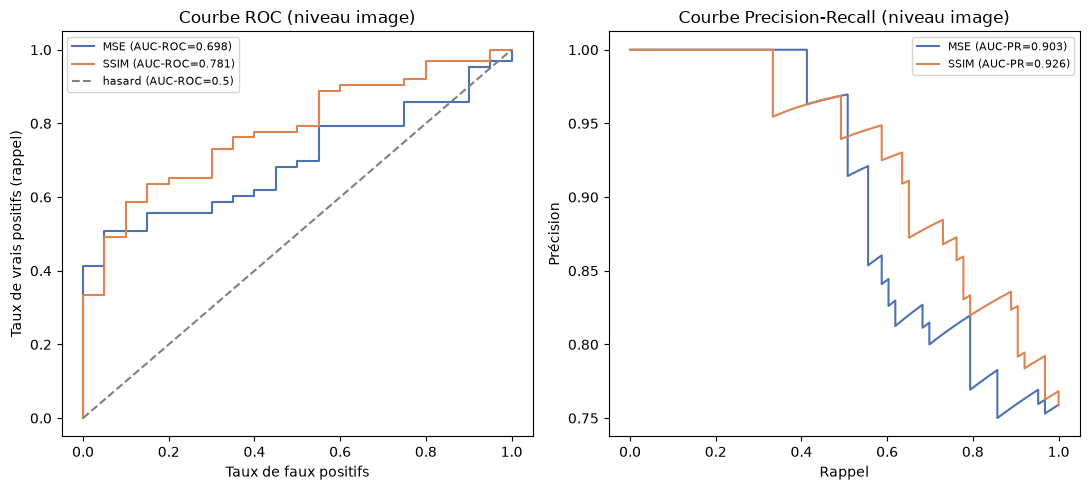

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for name, color in [("MSE", "#4C72B0"), ("SSIM", "#DD8452")]:
    fpr_c, tpr_c, _ = roc_data[name]
    axes[0].plot(fpr_c, tpr_c, label=f"{name} (AUC-ROC={auroc_image[name]:.3f})", color=color)

    prec_c, rec_c, _ = pr_data[name]
    axes[1].plot(rec_c, prec_c, label=f"{name} (AUC-PR={aucpr_image[name]:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="hasard (AUC-ROC=0.5)")
axes[0].set_xlabel("Taux de faux positifs"); axes[0].set_ylabel("Taux de vrais positifs (rappel)")
axes[0].set_title("Courbe ROC (niveau image)"); axes[0].legend(fontsize=8)

axes[1].set_xlabel("Rappel"); axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Precision-Recall (niveau image)"); axes[1].legend(fontsize=8)

plt.tight_layout()

with mlflow.start_run(run_id=run_id_mse):
    mlflow.log_figure(fig, f"roc_pr_curves_image_level_{run_id_mse}.png")

plt.show()

### Effet du passage à un score pixel-level : localisation via IoU

Les métriques précédentes (AUC-ROC/AUC-PR image-level) répondent à "l'image est-elle défectueuse ?", pas à "où est le défaut ?". En s'appuyant sur `ground_truth/` (étape 3.11), on calibre un **seuil pixel** (analogue au seuil image de l'étape 19, mais appliqué à chaque pixel de la heatmap plutôt qu'à la moyenne par image), on binarise la heatmap pour obtenir un **masque de segmentation prédit**, puis on le compare au masque réel via l'**IoU** (Intersection over Union).

Ce score pixel-level répond à une question différente et complémentaire du score image-level : une image peut être "manquée" au niveau image (score moyen sous le seuil, cf. étape 21 "analyse des ratés") tout en ayant une heatmap qui localise correctement la zone du défaut — l'information n'est simplement pas assez concentrée pour faire remonter la moyenne globale au-dessus du seuil image. Le passage au pixel-level permet de récupérer cette information "diluée".

In [220]:
def iou_score(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()
    return intersection / union if union > 0 else 1.0


PIXEL_THRESHOLD_PERCENTILE = 99  # calibré sur les pixels des images saines de validation

pixel_thresholds, ious_per_algo = {}, {}

for name, (model, rid) in models.items():
    val_heatmaps, _ = collect_pixel_arrays(model, val_ds)
    pixel_threshold = np.percentile(val_heatmaps.flatten(), PIXEL_THRESHOLD_PERCENTILE)
    pixel_thresholds[name] = pixel_threshold

    all_heatmaps, all_masks = pixel_data[name]
    defect_indices = [i for i in range(len(all_masks)) if all_masks[i].sum() > 0]  # images réellement défectueuses uniquement

    ious = []
    for i in defect_indices:
        pred_mask = (all_heatmaps[i] > pixel_threshold).astype(np.uint8)
        ious.append(iou_score(pred_mask, all_masks[i]))
    ious_per_algo[name] = np.array(ious)

    with mlflow.start_run(run_id=rid):
        mlflow.log_metrics({"pixel_threshold_p99": pixel_threshold, "mean_iou": ious_per_algo[name].mean()})

    print(f"[{name}] seuil pixel (p{PIXEL_THRESHOLD_PERCENTILE} val) = {pixel_threshold:.5f}  "
          f"IoU moyen = {ious_per_algo[name].mean():.4f}  (sur {len(ious)} images défectueuses)")

[MSE] seuil pixel (p99 val) = 0.02382  IoU moyen = 0.0873  (sur 63 images défectueuses)
[SSIM] seuil pixel (p99 val) = 0.01430  IoU moyen = 0.0620  (sur 63 images défectueuses)


**Rendu — exemple de segmentation prédite vs masque réel**, sur l'image défectueuse la mieux segmentée (IoU max) et la moins bien segmentée (IoU min), par algorithme.

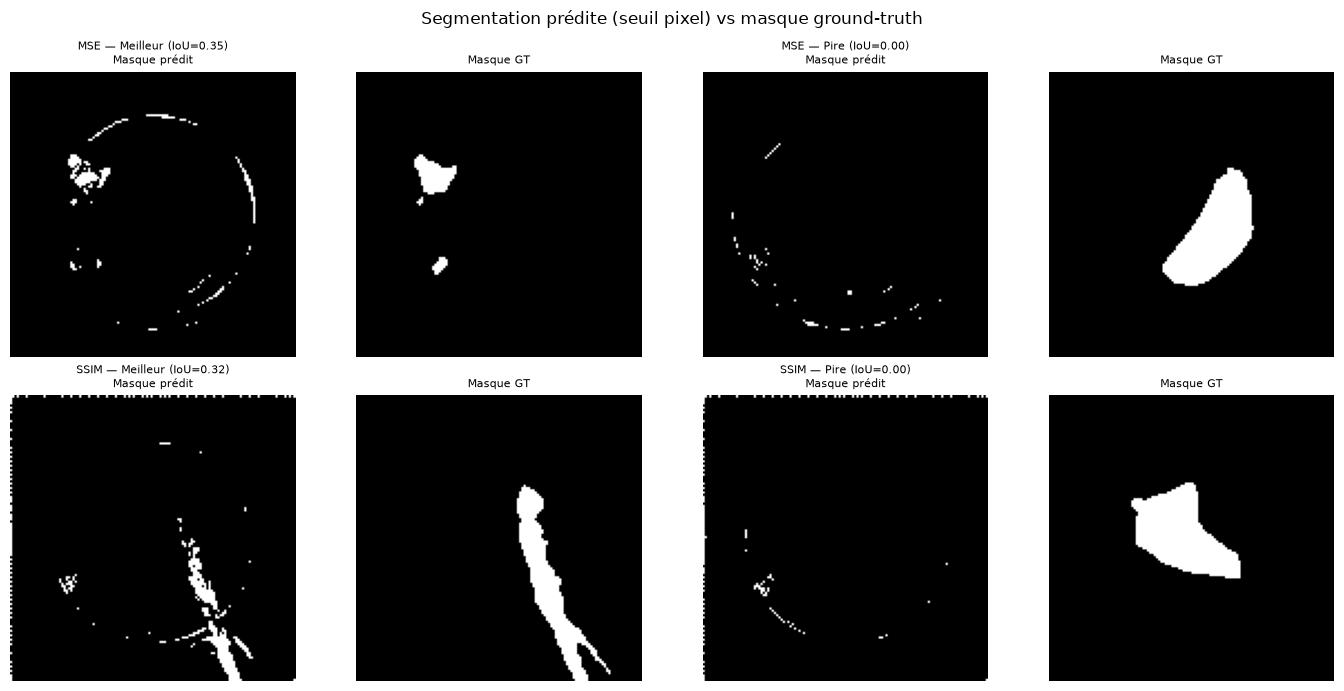

In [221]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, name in enumerate(["MSE", "SSIM"]):
    all_heatmaps, all_masks = pixel_data[name]
    defect_indices = [i for i in range(len(all_masks)) if all_masks[i].sum() > 0]
    ious = ious_per_algo[name]
    best_idx = defect_indices[int(np.argmax(ious))]
    worst_idx = defect_indices[int(np.argmin(ious))]

    for col, (idx, label) in enumerate([(best_idx, f"Meilleur (IoU={ious.max():.2f})"),
                                          (worst_idx, f"Pire (IoU={ious.min():.2f})")]):
        pred_mask = (all_heatmaps[idx] > pixel_thresholds[name]).astype(np.uint8)
        axes[row, col*2].imshow(pred_mask, cmap="gray")
        axes[row, col*2].set_title(f"{name} — {label}\nMasque prédit", fontsize=8)
        axes[row, col*2].axis("off")
        axes[row, col*2+1].imshow(all_masks[idx], cmap="gray")
        axes[row, col*2+1].set_title("Masque GT", fontsize=8)
        axes[row, col*2+1].axis("off")

plt.suptitle("Segmentation prédite (seuil pixel) vs masque ground-truth")
plt.tight_layout()

with mlflow.start_run(run_id=run_id_mse):
    mlflow.log_figure(fig, f"iou_segmentation_examples_{run_id_mse}.png")

plt.show()

**Synthèse image-level vs pixel-level** : les deux échelles répondent à des questions différentes et se complètent — l'AUC-ROC/AUC-PR image-level évalue la détection globale, l'AUC-PR pixel-level et l'IoU évaluent la localisation. Un score élevé à l'un ne garantit pas un score élevé à l'autre (ex. un modèle peut bien discriminer sain/défectueux globalement tout en localisant mal le défaut précis, ou inversement). Pour un cas d'usage qui nécessite de montrer *où* est le défaut (pas seulement *qu'il y en a un*), l'IoU pixel-level est la métrique qui compte, pas l'AUC-ROC image-level.

### Matrice de confusion (au seuil calibré, étape 19)

Au seuil percentile (p95) déjà calibré, une image est classée "défectueuse" si son score dépasse le seuil. La matrice de confusion image-level en résulte, une par algorithme.

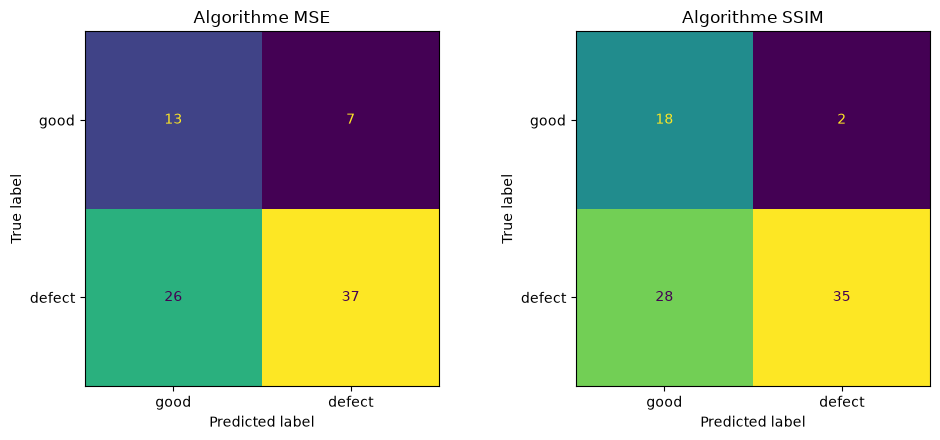

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, name in zip(axes, ["MSE", "SSIM"]):
    y_true_img = np.concatenate([np.zeros(len(scores[name]["good"])), np.ones(len(scores[name]["defect"]))])
    y_score_img = np.concatenate([scores[name]["good"], scores[name]["defect"]])
    y_pred_img = (y_score_img > thresholds[name]).astype(int)

    cm = confusion_matrix(y_true_img, y_pred_img)
    ConfusionMatrixDisplay(cm, display_labels=["good", "defect"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"Algorithme {name}")

plt.tight_layout()
plt.show()

### Analyse des ratés

Au-delà des chiffres agrégés, regarder concrètement **ce qui est mal classé** : les défauts manqués (faux négatifs — score sous le seuil malgré un vrai défaut) et les fausses alertes (faux positifs — score au-dessus du seuil sur une image saine). Jusqu'à 3 exemples de chaque, par algorithme.

[MSE] Défauts manqués : 3/3 affichés (total réel : 26/63)
[MSE] Fausses alertes : 3/3 affichés (total réel : 7/20)


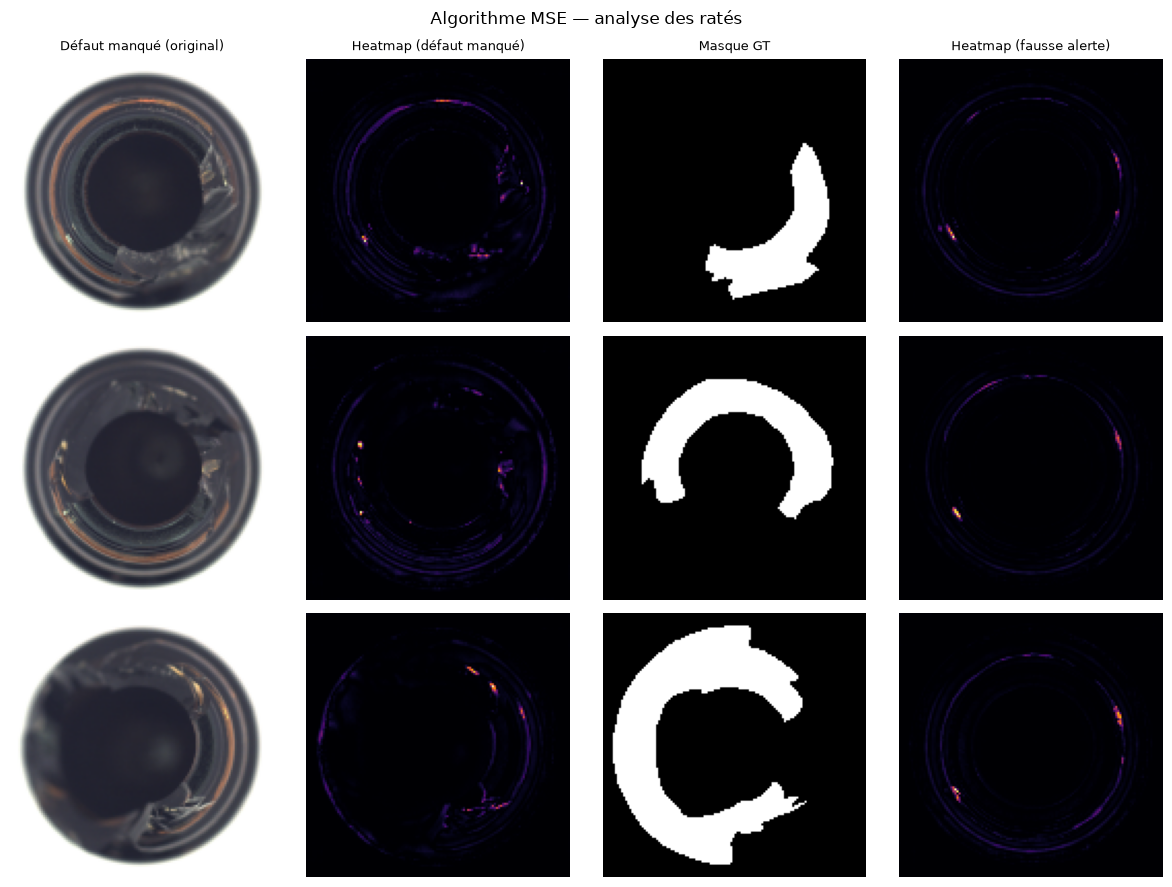

[SSIM] Défauts manqués : 3/3 affichés (total réel : 28/63)
[SSIM] Fausses alertes : 2/3 affichés (total réel : 2/20)


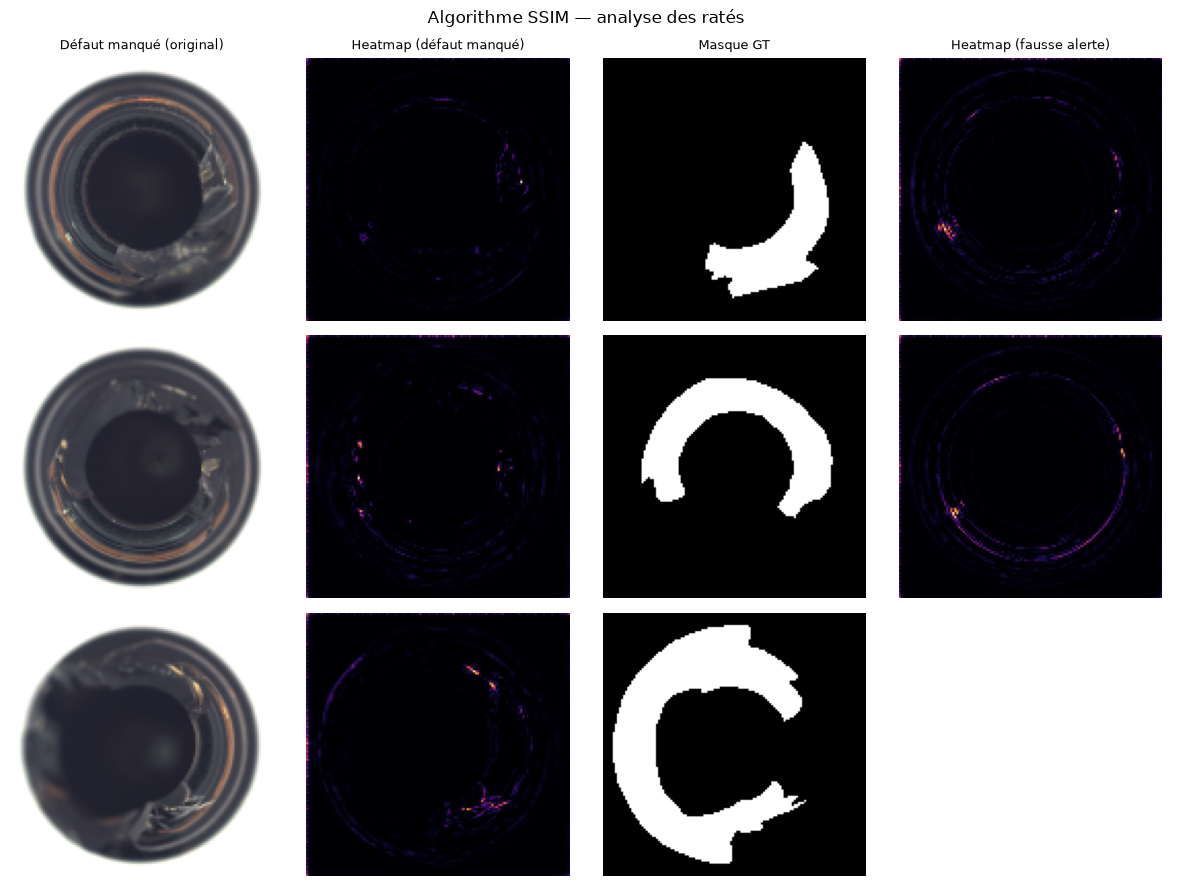

In [223]:
def images_and_scores(model, dataset):
    """Concatène les images et leurs scores de reconstruction (MSE par image) d'un dataset."""
    imgs_list, scores_list = [], []
    for batch in dataset:
        recon = model(batch)
        err = tf.reduce_mean(tf.square(batch - recon), axis=[1, 2, 3])
        imgs_list.append(batch.numpy())
        scores_list.append(err.numpy())
    return np.concatenate(imgs_list, axis=0), np.concatenate(scores_list, axis=0)


def plot_failure_examples(model, name, max_examples=3):
    threshold = thresholds[name]

    good_imgs, good_scores_ = images_and_scores(model, test_good_ds)

    defect_imgs_list, defect_masks_list, defect_scores_list = [], [], []
    for dname in defect_names:
        imgs_d, scores_d = images_and_scores(model, test_defect_ds[dname])
        defect_imgs_list.append(imgs_d)
        defect_scores_list.append(scores_d)
        defect_masks_list.append(test_defect_masks[dname])
    defect_imgs = np.concatenate(defect_imgs_list, axis=0)
    defect_scores_ = np.concatenate(defect_scores_list, axis=0)
    defect_masks_all = np.concatenate(defect_masks_list, axis=0)

    missed_idx = np.where(defect_scores_ <= threshold)[0][:max_examples]     # faux négatifs
    false_alarm_idx = np.where(good_scores_ > threshold)[0][:max_examples]   # faux positifs

    n_missed, n_false_alarm = len(missed_idx), len(false_alarm_idx)
    n_rows = max(n_missed, n_false_alarm, 1)

    fig, axes = plt.subplots(n_rows, 4, figsize=(12, 3 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    for ax in axes.ravel():
        ax.axis("off")

    col_titles = ["Défaut manqué (original)", "Heatmap (défaut manqué)", "Masque GT", "Heatmap (fausse alerte)"]
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=9)

    for row in range(n_missed):
        idx = missed_idx[row]
        img, mask = defect_imgs[idx], defect_masks_all[idx]
        recon = model(tf.expand_dims(img, 0))[0]
        heatmap = error_heatmap(img, recon).numpy()
        axes[row, 0].imshow(img)
        axes[row, 1].imshow(heatmap, cmap="inferno")
        axes[row, 2].imshow(mask, cmap="gray")

    for row in range(n_false_alarm):
        idx = false_alarm_idx[row]
        img = good_imgs[idx]
        recon = model(tf.expand_dims(img, 0))[0]
        heatmap = error_heatmap(img, recon).numpy()
        axes[row, 3].imshow(heatmap, cmap="inferno")

    print(f"[{name}] Défauts manqués : {n_missed}/{max_examples} affichés (total réel : {(defect_scores_ <= threshold).sum()}/{len(defect_scores_)})")
    print(f"[{name}] Fausses alertes : {n_false_alarm}/{max_examples} affichés (total réel : {(good_scores_ > threshold).sum()}/{len(good_scores_)})")

    plt.suptitle(f"Algorithme {name} — analyse des ratés")
    plt.tight_layout()
    return fig


for name, (model, rid) in models.items():
    fig = plot_failure_examples(model, name)
    with mlflow.start_run(run_id=rid):
        mlflow.log_figure(fig, f"failure_analysis_{rid}.png")
    plt.show()

**Lecture** : les défauts manqués sont typiquement les plus petits ou les moins contrastés (zone de défaut réduite, erreur de reconstruction diluée dans la moyenne globale de l'image) — cohérent avec l'étude de déséquilibre pixel-level (étape 3.11), où `broken_small` a la plus faible fraction de pixels défectueux. Les fausses alertes viennent souvent d'images saines avec une texture ou un éclairage légèrement atypique, que le modèle n'a pas assez vu à l'entraînement (peu de données, augmentation limitée). Ces deux constats orientent les pistes d'amélioration : plus de données/augmentation pour réduire les fausses alertes, un score pixel-level (déjà disponible via la heatmap) plutôt qu'image-level pour mieux capter les petits défauts.

## 22. Décision finale : modèle retenu, seuil ajusté et IoU par image

**Modèle retenu : algorithme SSIM.** Justification, à partir des métriques déjà calculées dans les étapes précédentes (pas de nouvel entraînement) :
- Étape 19 (p95 par défaut) : rappel 63-75 % et faux positifs proches de la cible (~5-10 %) pour SSIM, contre un rappel comparable mais des faux positifs 4 à 8x supérieurs à la cible pour MSE (35-40 %).
- Étape 19 (généralisation `val` vs `test/good`) : la distribution des scores SSIM se transporte correctement de la validation vers le test ; celle de MSE non.
- Étape 21 (AUC-ROC/AUC-PR, IoU) : cohérent avec ce qui précède sur cette exécution.

Le reste de cette section ne relance **aucun entraînement** et ne recalcule **aucune reconstruction** — tout réutilise `scores["SSIM"]`, `pixel_data["SSIM"]` et `threshold_sweep["SSIM"]` déjà en mémoire, calculés une seule fois dans les étapes 19 et 21.

In [224]:
_t_final_section = time.time()  # chronométrage local de cette section (calibration + IoU par image)

model_final_name = "SSIM"
model_final, run_id_final = models[model_final_name]

### Ajustement du percentile de calibration

Plutôt que de garder le p95 par défaut (choisi arbitrairement en étape 19), on sélectionne le percentile qui **maximise l'indice de Youden** (`rappel - faux positifs`) sur le balayage déjà calculé (étape 19-20) pour l'algorithme SSIM — le point qui équilibre le mieux détection et fausses alertes, plutôt qu'un choix par défaut non justifié.

In [225]:
sweep = threshold_sweep[model_final_name]
youden = sweep["recall"] - sweep["fpr"]
best_idx = int(np.argmax(youden))
FINAL_PERCENTILE = int(sweep["percentiles"][best_idx])

print(f"Percentile retenu : p{FINAL_PERCENTILE}  "
      f"(indice de Youden = {youden[best_idx]:.3f}, rappel = {sweep['recall'][best_idx]:.2%}, FP = {sweep['fpr'][best_idx]:.2%})")
print(f"Pour comparaison, p95 par défaut : rappel = {recalls[model_final_name]:.2%}, FP = {fprs[model_final_name]:.2%}")

final_threshold_image = np.percentile(scores[model_final_name]["val"], FINAL_PERCENTILE)

with mlflow.start_run(run_id=run_id_final):
    mlflow.log_params({"final_model": model_final_name, "final_percentile": FINAL_PERCENTILE})
    mlflow.log_metric("final_threshold_image", final_threshold_image)

Percentile retenu : p94  (indice de Youden = 0.453, rappel = 60.32%, FP = 15.00%)
Pour comparaison, p95 par défaut : rappel = 55.56%, FP = 10.00%


### Seuil de segmentation pixel et IoU par image (étape 21, percentile ajusté)

Même principe que l'étape 21, mais avec `FINAL_PERCENTILE` (au lieu de p99 fixe) et **pour chaque image défectueuse individuellement** — pas seulement la meilleure/pire.

In [226]:
val_heatmaps_final, _ = collect_pixel_arrays(model_final, val_ds)  # seul nouveau passage forward de cette section (sur val_ds uniquement, petit)
pixel_threshold_final = np.percentile(val_heatmaps_final.flatten(), FINAL_PERCENTILE)

all_heatmaps_final, all_masks_final = pixel_data[model_final_name]  # déjà calculé en étape 21, réutilisé tel quel

# Reconstitution de la liste (classe de défaut, index) dans l'ordre de concaténation de all_heatmaps_final/all_masks_final
image_labels = ["good"] * len(scores[model_final_name]["good"])
for dname in defect_names:
    image_labels += [dname] * len(test_defect_masks[dname])

iou_rows = []
for i, (label, heatmap, mask) in enumerate(zip(image_labels, all_heatmaps_final, all_masks_final)):
    if mask.sum() == 0:
        continue  # IoU non défini sur les images saines (pas de défaut à segmenter)
    pred_mask = (heatmap > pixel_threshold_final).astype(np.uint8)
    iou_rows.append({"index_global": i, "classe_defaut": label, "iou": iou_score(pred_mask, mask)})

print(f"Seuil pixel (p{FINAL_PERCENTILE} val) = {pixel_threshold_final:.5f}\n")
print(f"{'Classe':<16} {'Index':>6} {'IoU':>8}")
for row in iou_rows:
    print(f"{row['classe_defaut']:<16} {row['index_global']:>6} {row['iou']:>8.4f}")

ious_final = np.array([row["iou"] for row in iou_rows])
print(f"\nIoU moyen (global, n={len(ious_final)}) : {ious_final.mean():.4f} (± {ious_final.std():.4f})")
for dname in defect_names:
    per_class = np.array([row["iou"] for row in iou_rows if row["classe_defaut"] == dname])
    print(f"  {dname:<16} IoU moyen = {per_class.mean():.4f}  (n={len(per_class)})")

with mlflow.start_run(run_id=run_id_final):
    mlflow.log_metrics({"pixel_threshold_final": pixel_threshold_final, "mean_iou_final": ious_final.mean()})

Seuil pixel (p94 val) = 0.00340

Classe            Index      IoU
broken_large         20   0.1043
broken_large         21   0.0986
broken_large         22   0.0524
broken_large         23   0.1131
broken_large         24   0.1798
broken_large         25   0.1191
broken_large         26   0.0830
broken_large         27   0.0705
broken_large         28   0.1059
broken_large         29   0.0588
broken_large         30   0.0592
broken_large         31   0.0756
broken_large         32   0.0705
broken_large         33   0.0793
broken_large         34   0.1248
broken_large         35   0.0944
broken_large         36   0.1185
broken_large         37   0.1215
broken_large         38   0.1276
broken_large         39   0.0830
broken_small         40   0.0441
broken_small         41   0.1101
broken_small         42   0.1383
broken_small         43   0.1184
broken_small         44   0.1872
broken_small         45   0.0446
broken_small         46   0.0711
broken_small         47   0.0499
broken_sma

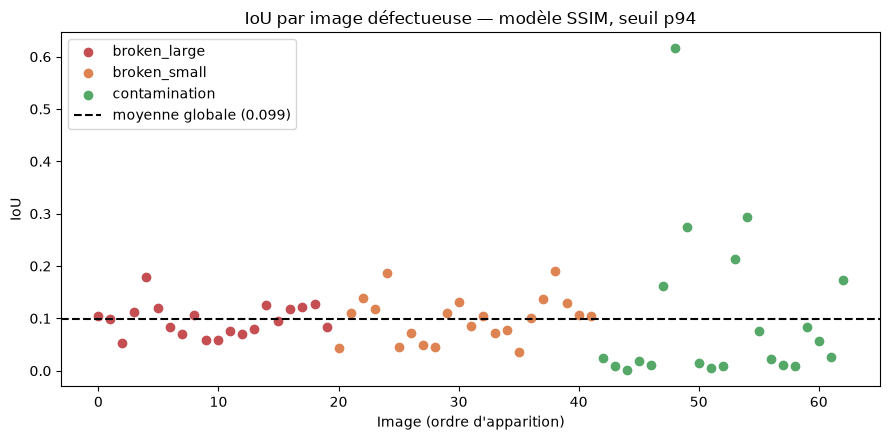


Temps de traitement de cette section (calibration + IoU par image) : 7.9 s


In [227]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors_map = {name: c for name, c in zip(defect_names, ["#C44E52", "#DD8452", "#55A868"])}
for dname in defect_names:
    idx = [i for i, row in enumerate(iou_rows) if row["classe_defaut"] == dname]
    ax.scatter(idx, [iou_rows[i]["iou"] for i in idx], label=dname, color=colors_map[dname])
ax.axhline(ious_final.mean(), color="black", linestyle="--", label=f"moyenne globale ({ious_final.mean():.3f})")
ax.set_xlabel("Image (ordre d'apparition)")
ax.set_ylabel("IoU")
ax.set_title(f"IoU par image défectueuse — modèle {model_final_name}, seuil p{FINAL_PERCENTILE}")
ax.legend()
plt.tight_layout()

with mlflow.start_run(run_id=run_id_final):
    mlflow.log_figure(fig, f"iou_per_image_{run_id_final}.png")

plt.show()

_final_section_elapsed = time.time() - _t_final_section
print(f"\nTemps de traitement de cette section (calibration + IoU par image) : {_final_section_elapsed:.1f} s")

**Lecture** : le percentile ajusté (Youden) donne un compromis rappel/FP déjà documenté en étape 19-20 pour ce point précis, ici appliqué de façon cohérente au seuil de segmentation pixel. La dispersion de l'IoU par classe de défaut (visible sur le graphique) reflète l'étude de déséquilibre pixel-level de l'étape 3.11 : les classes avec une plus faible fraction de pixels défectueux (`broken_small`) tendent à avoir un IoU plus bas, la zone à segmenter étant plus petite et donc plus sensible à un léger décalage du masque prédit.

## 23. Prochaine étape

Le modèle SSIM et le seuil ajusté (Youden, étape 22) constituent un point de départ solide, pas une valeur définitive. Pistes de suite :
- Valider le choix de percentile (Youden) sur un jeu de validation plus grand ou en k-fold, pour s'assurer qu'il ne dépend pas d'un split particulier.
- Ajuster le percentile selon le coût métier réel d'un faux positif vs d'un faux négatif, si celui-ci diffère de l'équilibre neutre implicite de l'indice de Youden.
- Aller au-delà du seuil fixe pour la segmentation : un post-traitement morphologique (érosion/dilatation, filtrage des petites composantes connexes) sur le masque prédit pourrait améliorer l'IoU sans changer le modèle.
- Si le temps de traitement reste un enjeu en production, envisager de ne réentraîner que le modèle retenu (SSIM) plutôt que les deux algorithmes en parallèle — la comparaison MSE vs SSIM (étapes 10-21) n'a besoin d'être rejouée que lors d'un changement d'architecture ou de dataset, pas à chaque itération.

## 24. Temps de traitement global

In [228]:
_total_elapsed = time.time() - _notebook_start_time
print(f"Temps total d'exécution du notebook : {_total_elapsed:.1f} s  ({_total_elapsed/60:.1f} min)")

Temps total d'exécution du notebook : 1639.6 s  (27.3 min)
